# Analytics - Product Quality
Date: 2026/04  
Summary: Este notebook representa a análise de qualidade do projeto RetinaScan, utilizando o modelo de qualidade Q-RAPIDS.

---

## Equipe
* Semester: 2026/01
* Professor: Hilmer Neri
* Membros: - Natália Morais 
           - André Maia
           - Arthur Ribeiro
           - Cecília Quaresma
           - Elias Oliveira
           - Eric Camargo
           - Gustavo Costa
           - Harleny Angelica
           - Iderlan Junio
           - Vinicius Roriz
           - Yan Luca
           - Zenilda Vieira


---

## Metodologia e Processamento de Dados

O pipeline de dados realiza o *unmarshalling* de arquivos JSON provenientes do **SonarCloud**, filtrando componentes por tipo:
* FIL (Files): Arquivos de código fonte.
* DIR (Directories): Diretórios do projeto.
* UTS (Unit Test Suites): Suítes de testes unitários.

As métricas são calculadas por densidade de conformidade. O resultado de cada métrica representa a porcentagem de arquivos que atendem a um critério de qualidade específico (*threshold*).

---

## Modelo de Qualidade (Q-RAPIDS)

O cálculo final é dividido em dois Aspectos de Qualidade, cada um composto por um Fator de Qualidade.

### 1. Maintainability (Manutenibilidade)
Baseada no fator Code Quality. A nota é composta pelas métricas:
* Complexity: Proporção de arquivos com complexidade ciclomática média por função `< 10`.
* Comments: Proporção de arquivos com densidade de comentários entre `10%` e `30%`.
* Duplication: Proporção de arquivos com densidade de duplicação `< 5%`.

> Fórmula: $Code Quality = (Compl \times 0.33) + (Comm \times 0.33) + (Dupl \times 0.33)$

### 2. Reliability (Confiabilidade)
Baseada no fator Testing Status. A nota é composta pelas métricas:
* Passed Tests: Proporção de testes que passaram sem erros ou falhas.
* Fast Test Builds: Proporção de builds de teste com tempo de execução `< 300.000ms` (5 min).
* Coverage: Proporção de arquivos com cobertura de testes `> 60%`.

> Fórmula: $Testing Status = (Success \times 0.25) + (Fast \times 0.25) + (Cov \times 0.50)$

---

## Pesos e Notas Máximas

Conforme definido no script de agregação, cada aspecto contribui com 50% para a nota total. Note que as escalas nos gráficos individuais respeitam estes limites:

| Indicador | Peso (pc) | Nota Máxima Possível |
| :--- | :--- | :--- |
| **Maintainability** | 0.5 | 0.5 |
| **Reliability** | 0.5 | 0.5 |
| **Total Quality Score** | - | 1.0 (Soma dos dois acima) |

---

## Visualizações

O notebook gera três níveis de visualização:
1.  Base Metrics: Evolução das métricas individuais (0 a 1).
2.  Quality Characteristic Indicator: Boxplots que mostram a estabilidade estatística da Manutenibilidade e Confiabilidade.
3.  Quality Score: Gráfico de evolução da nota final do projeto (soma ponderada de ambos os aspectos).

---

## Exportação
Os resultados consolidados são exportados para a pasta `./data/` nos formatos `.csv` e `.xlsx`, incluindo um *timestamp* para controle histórico de versões.

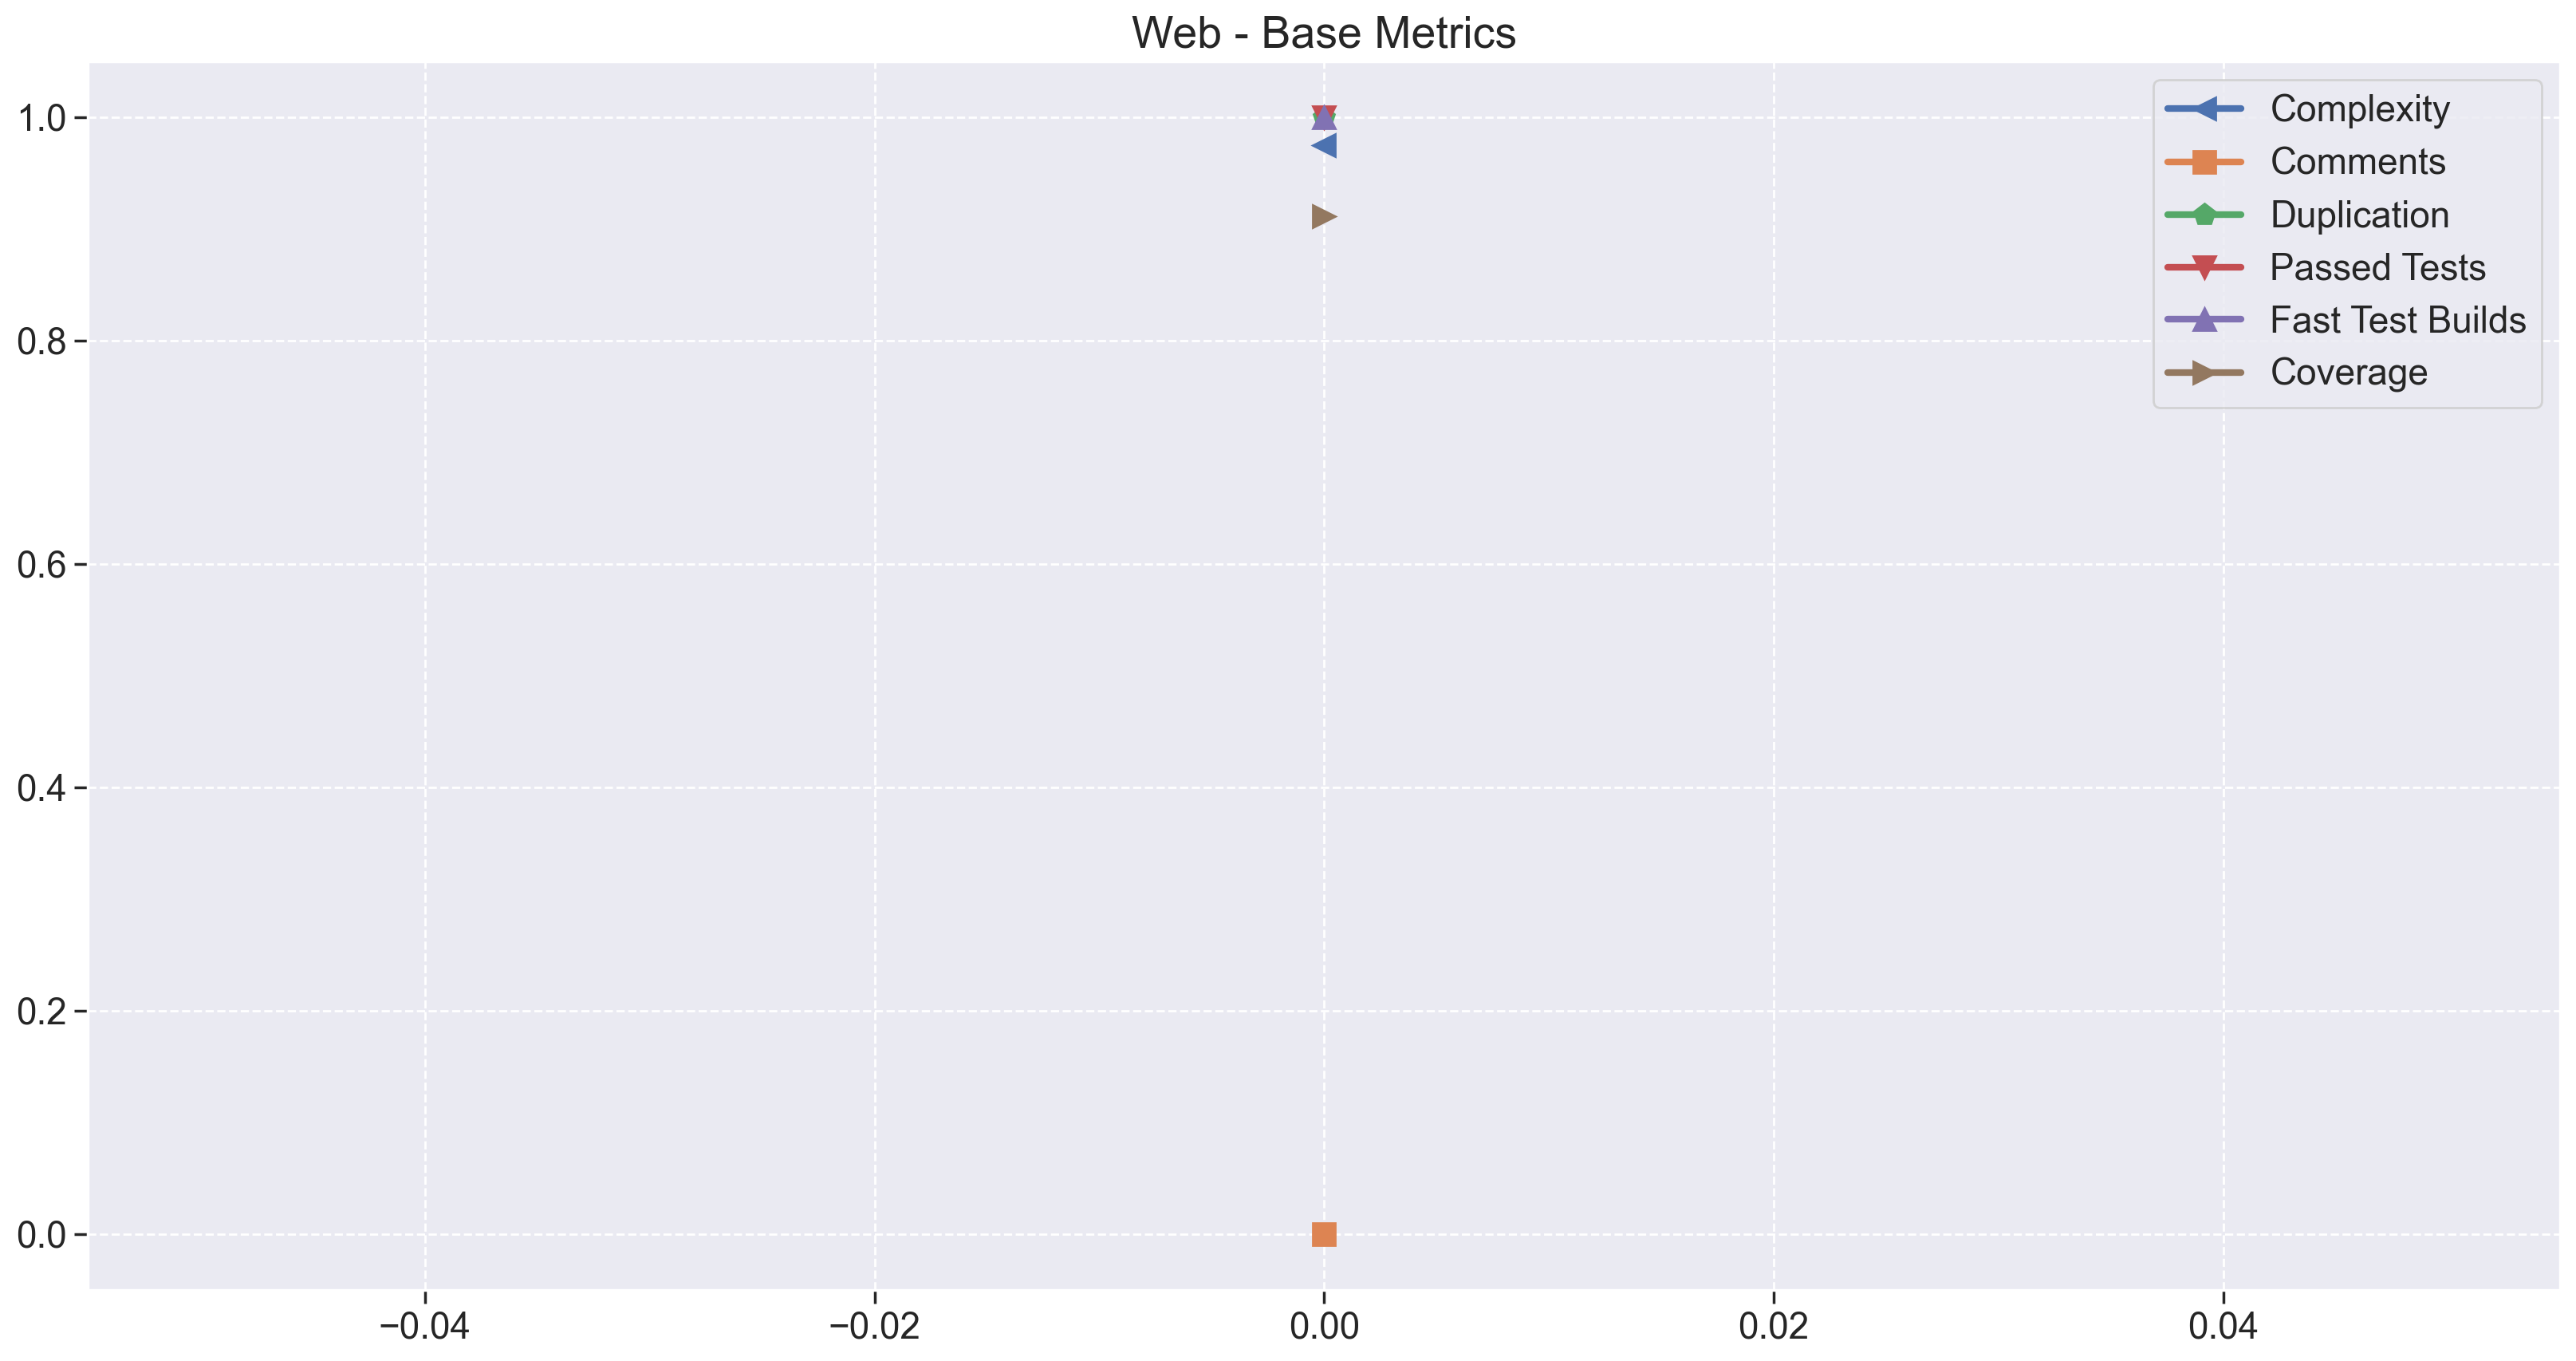

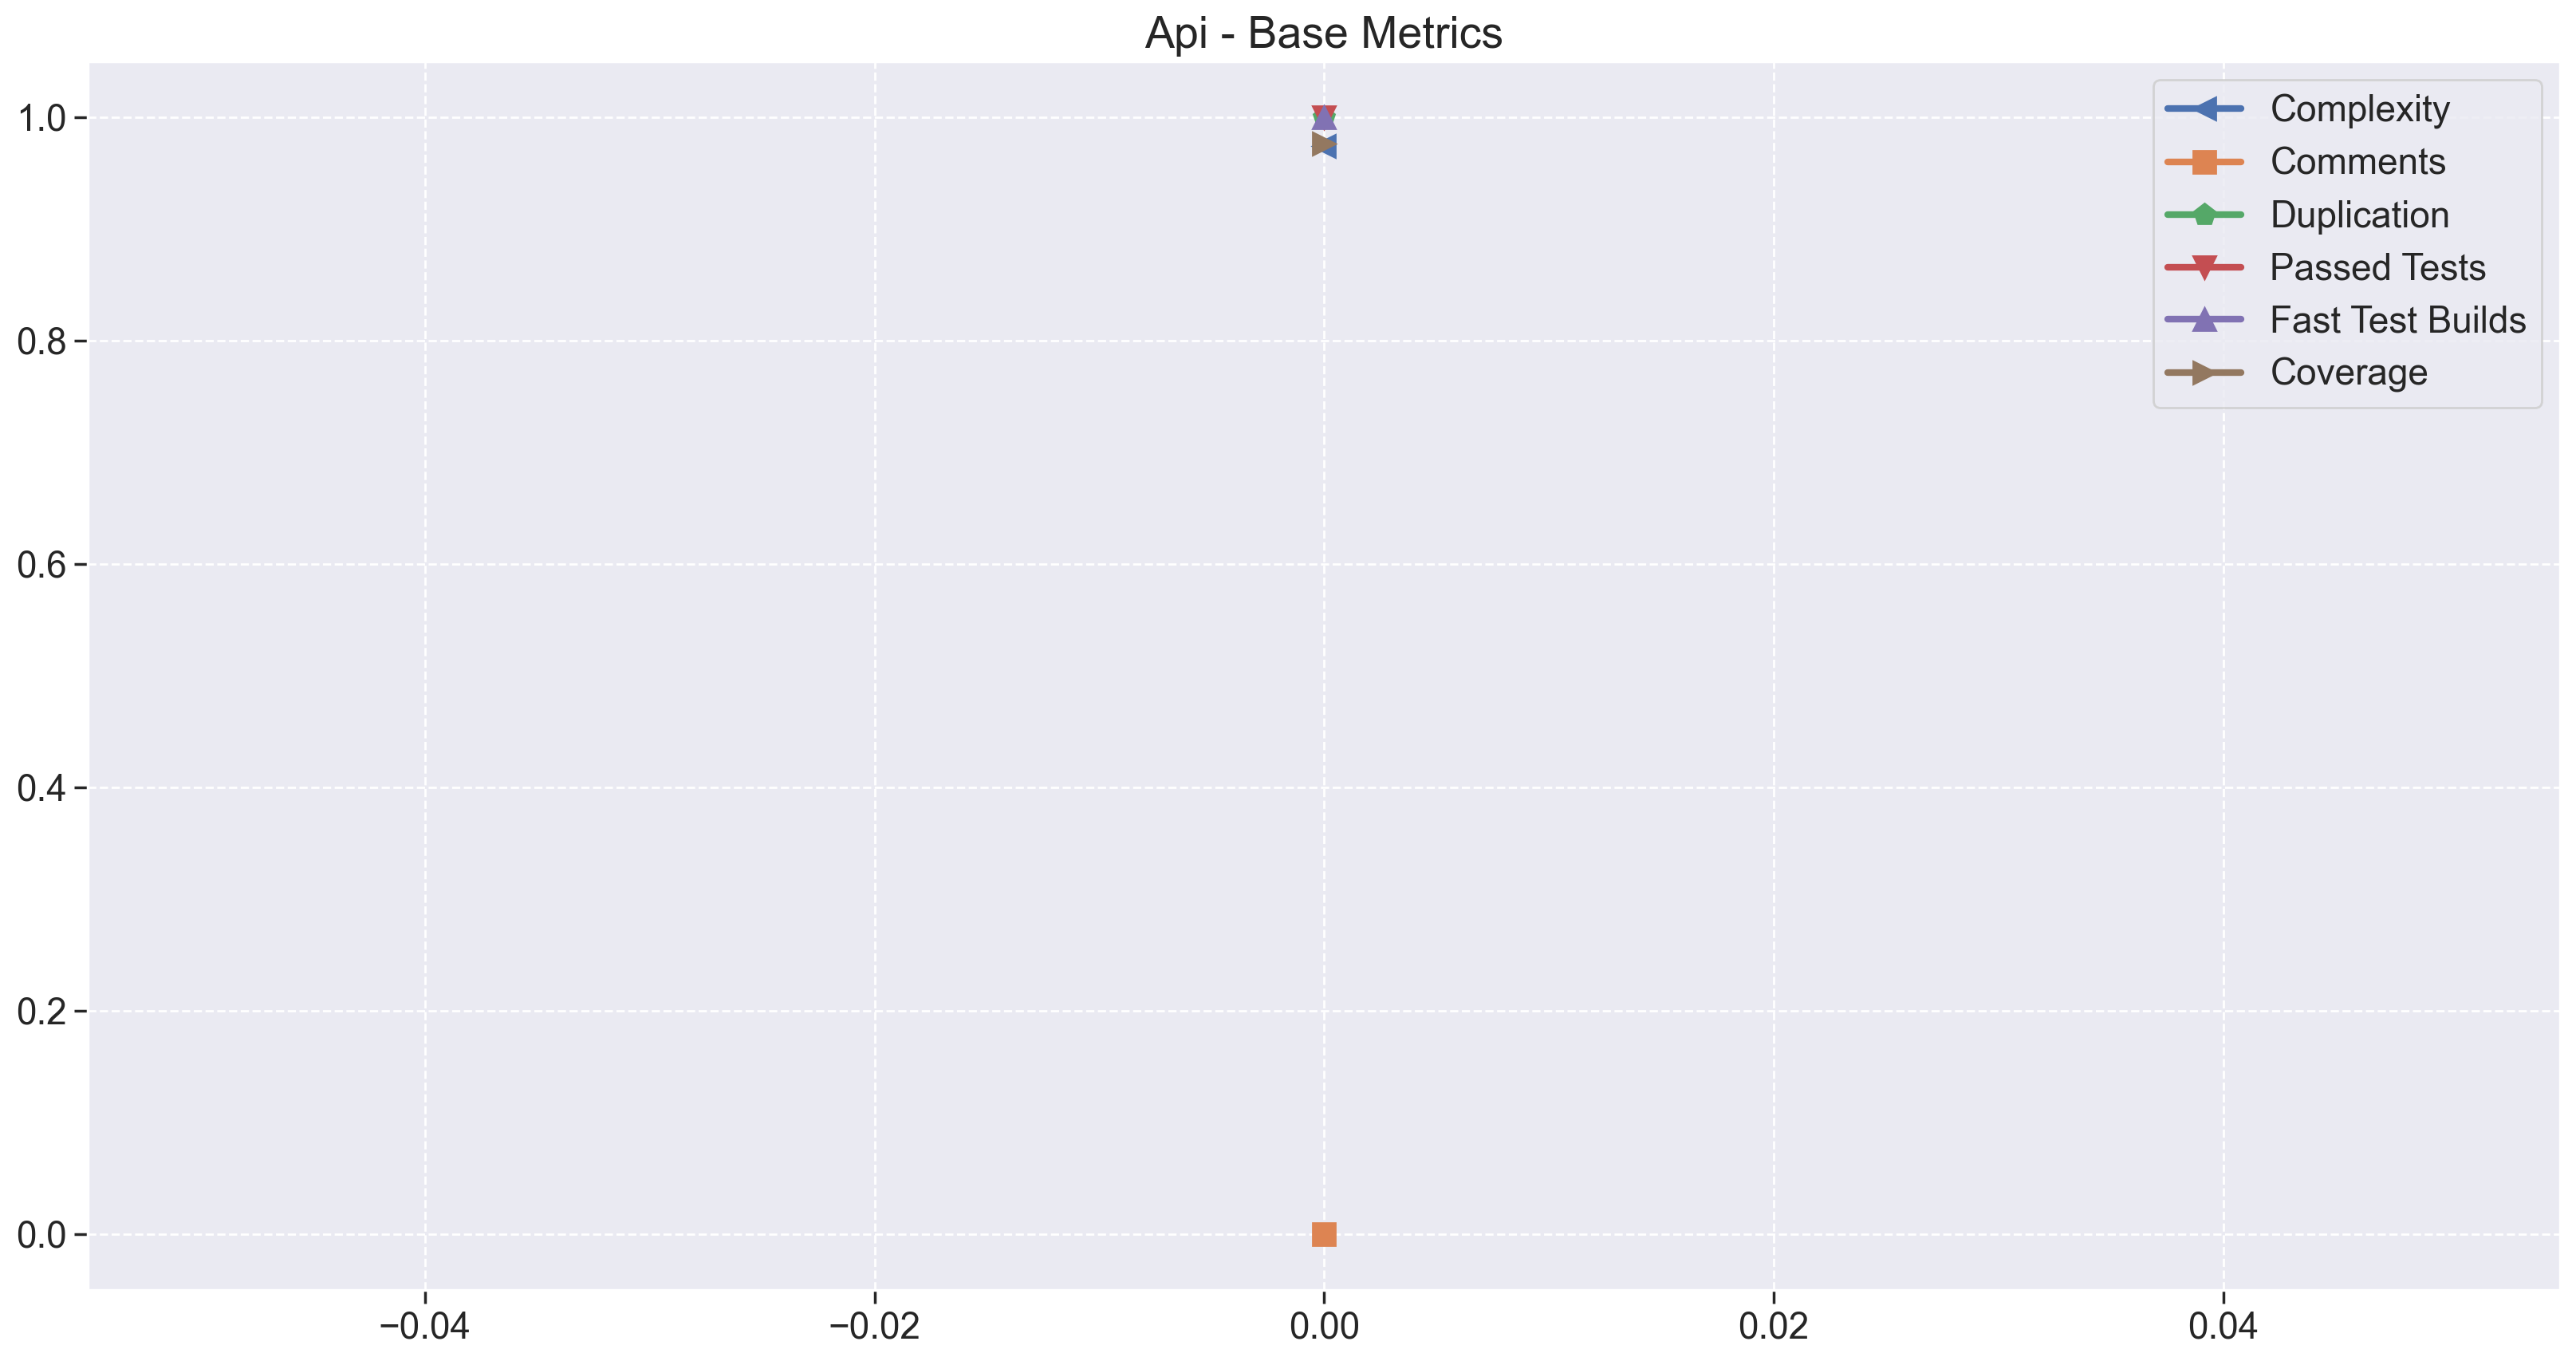

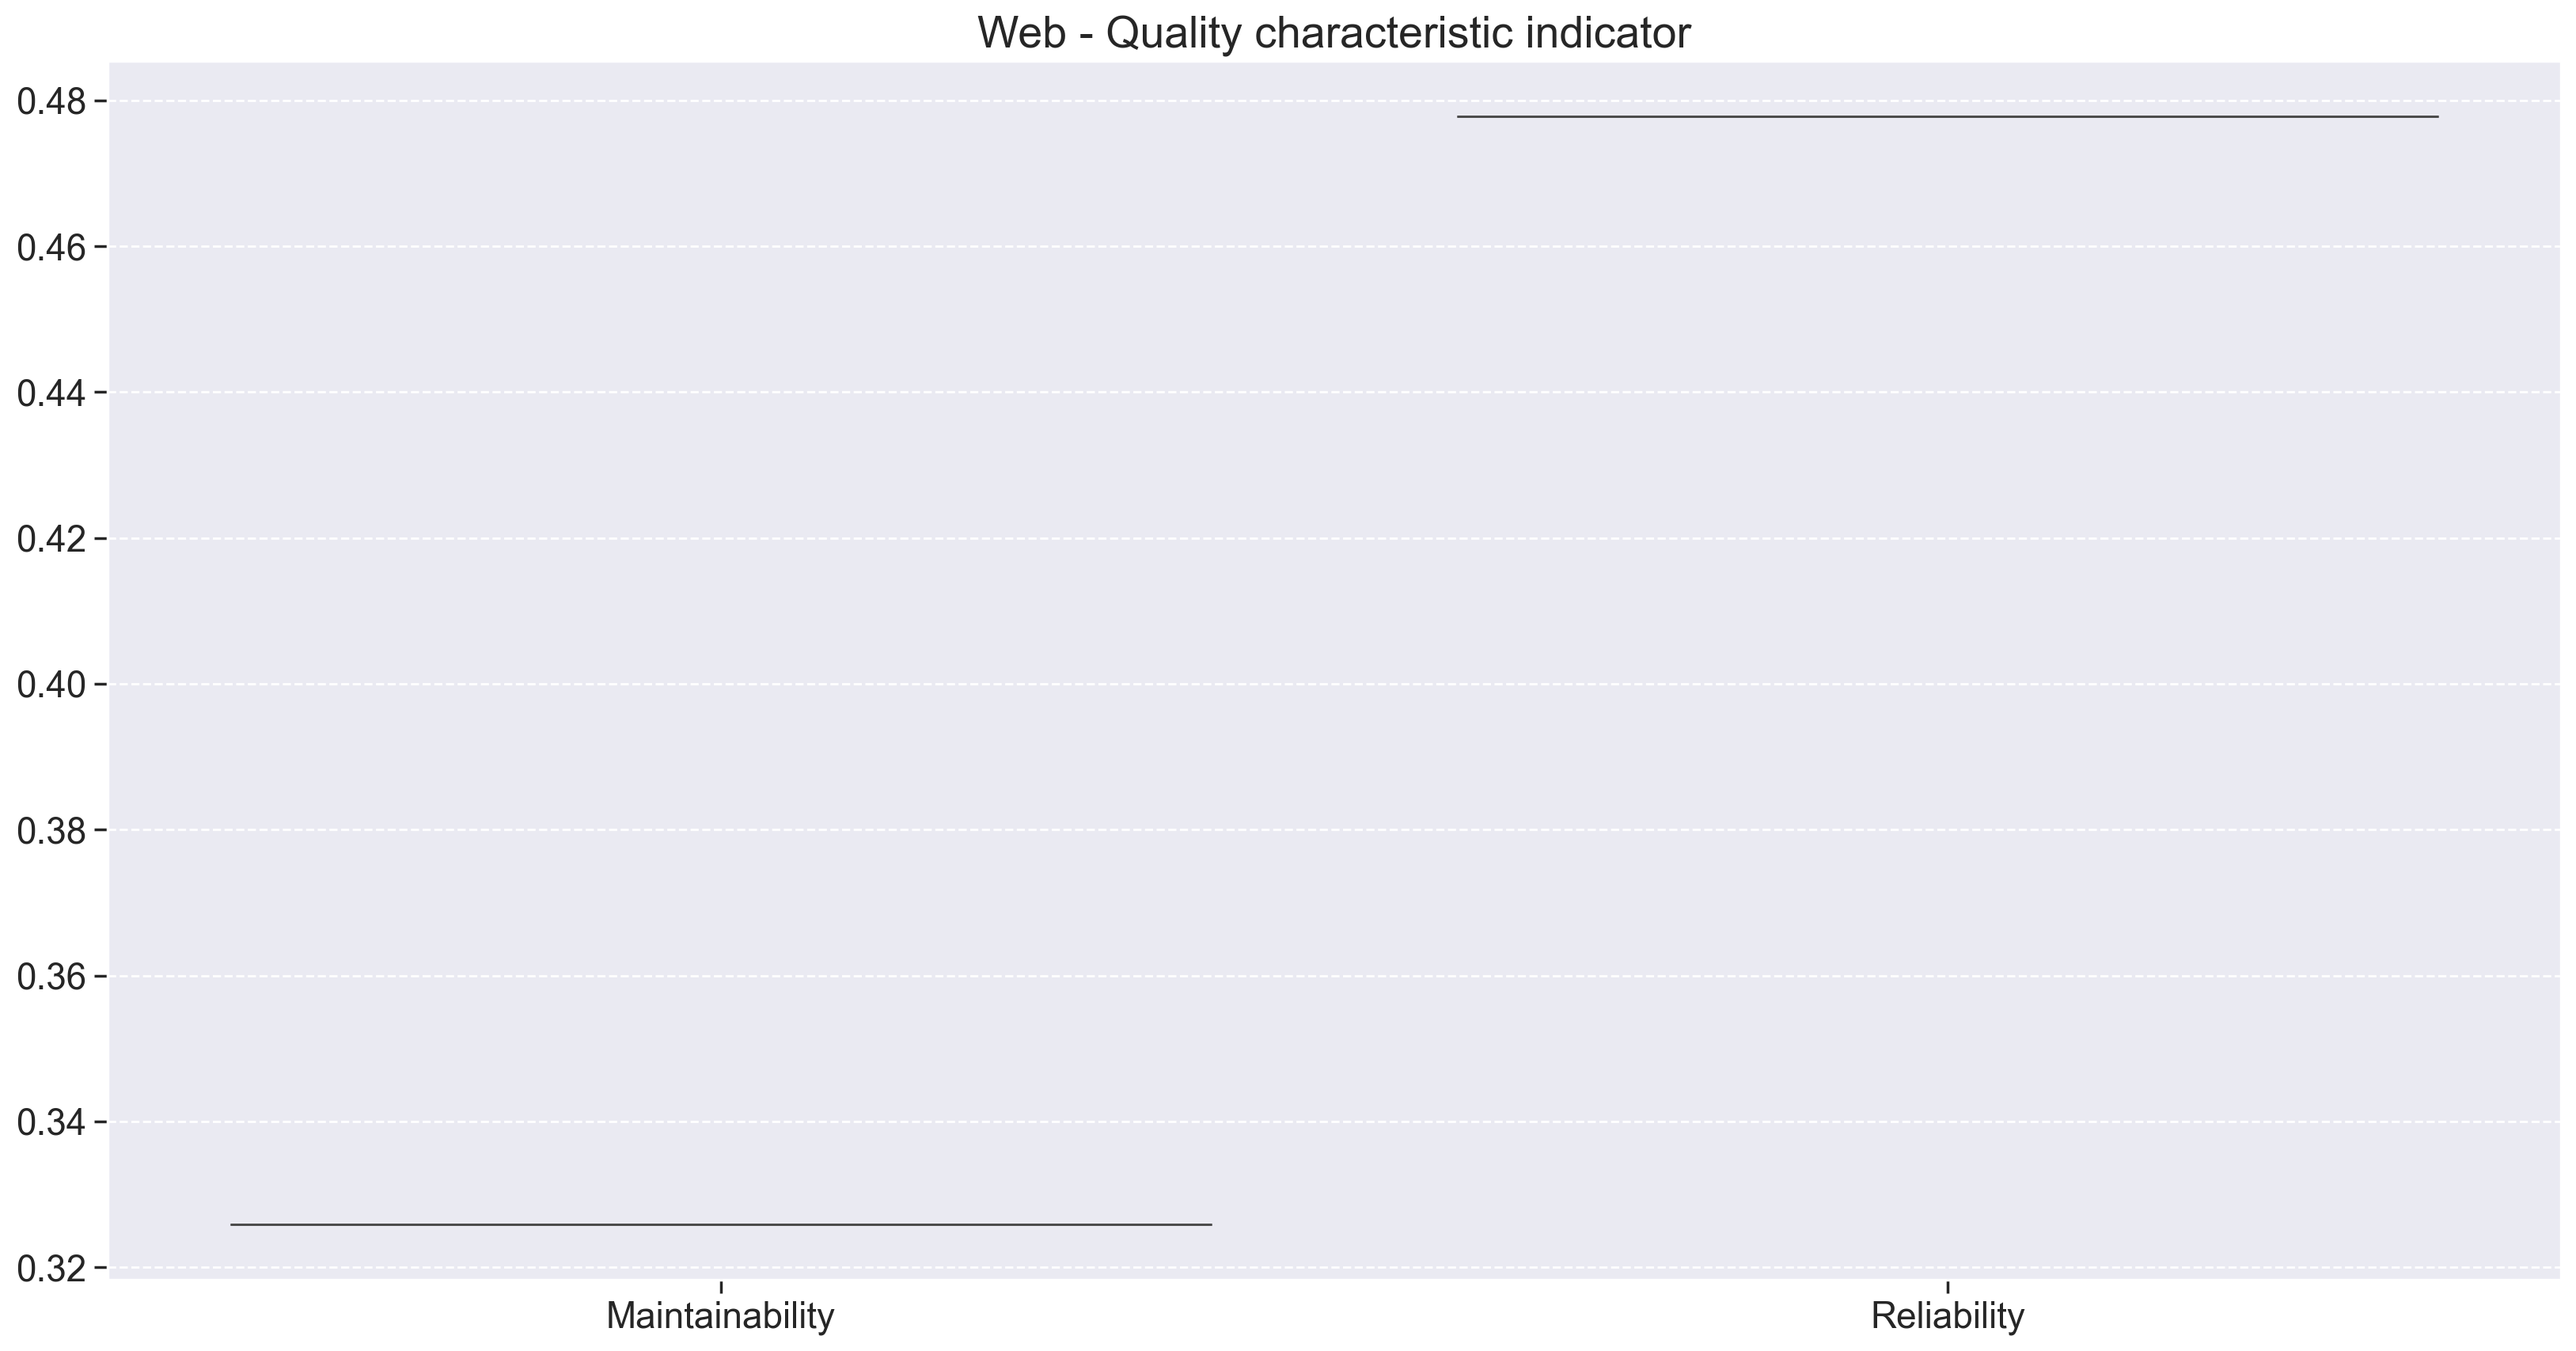

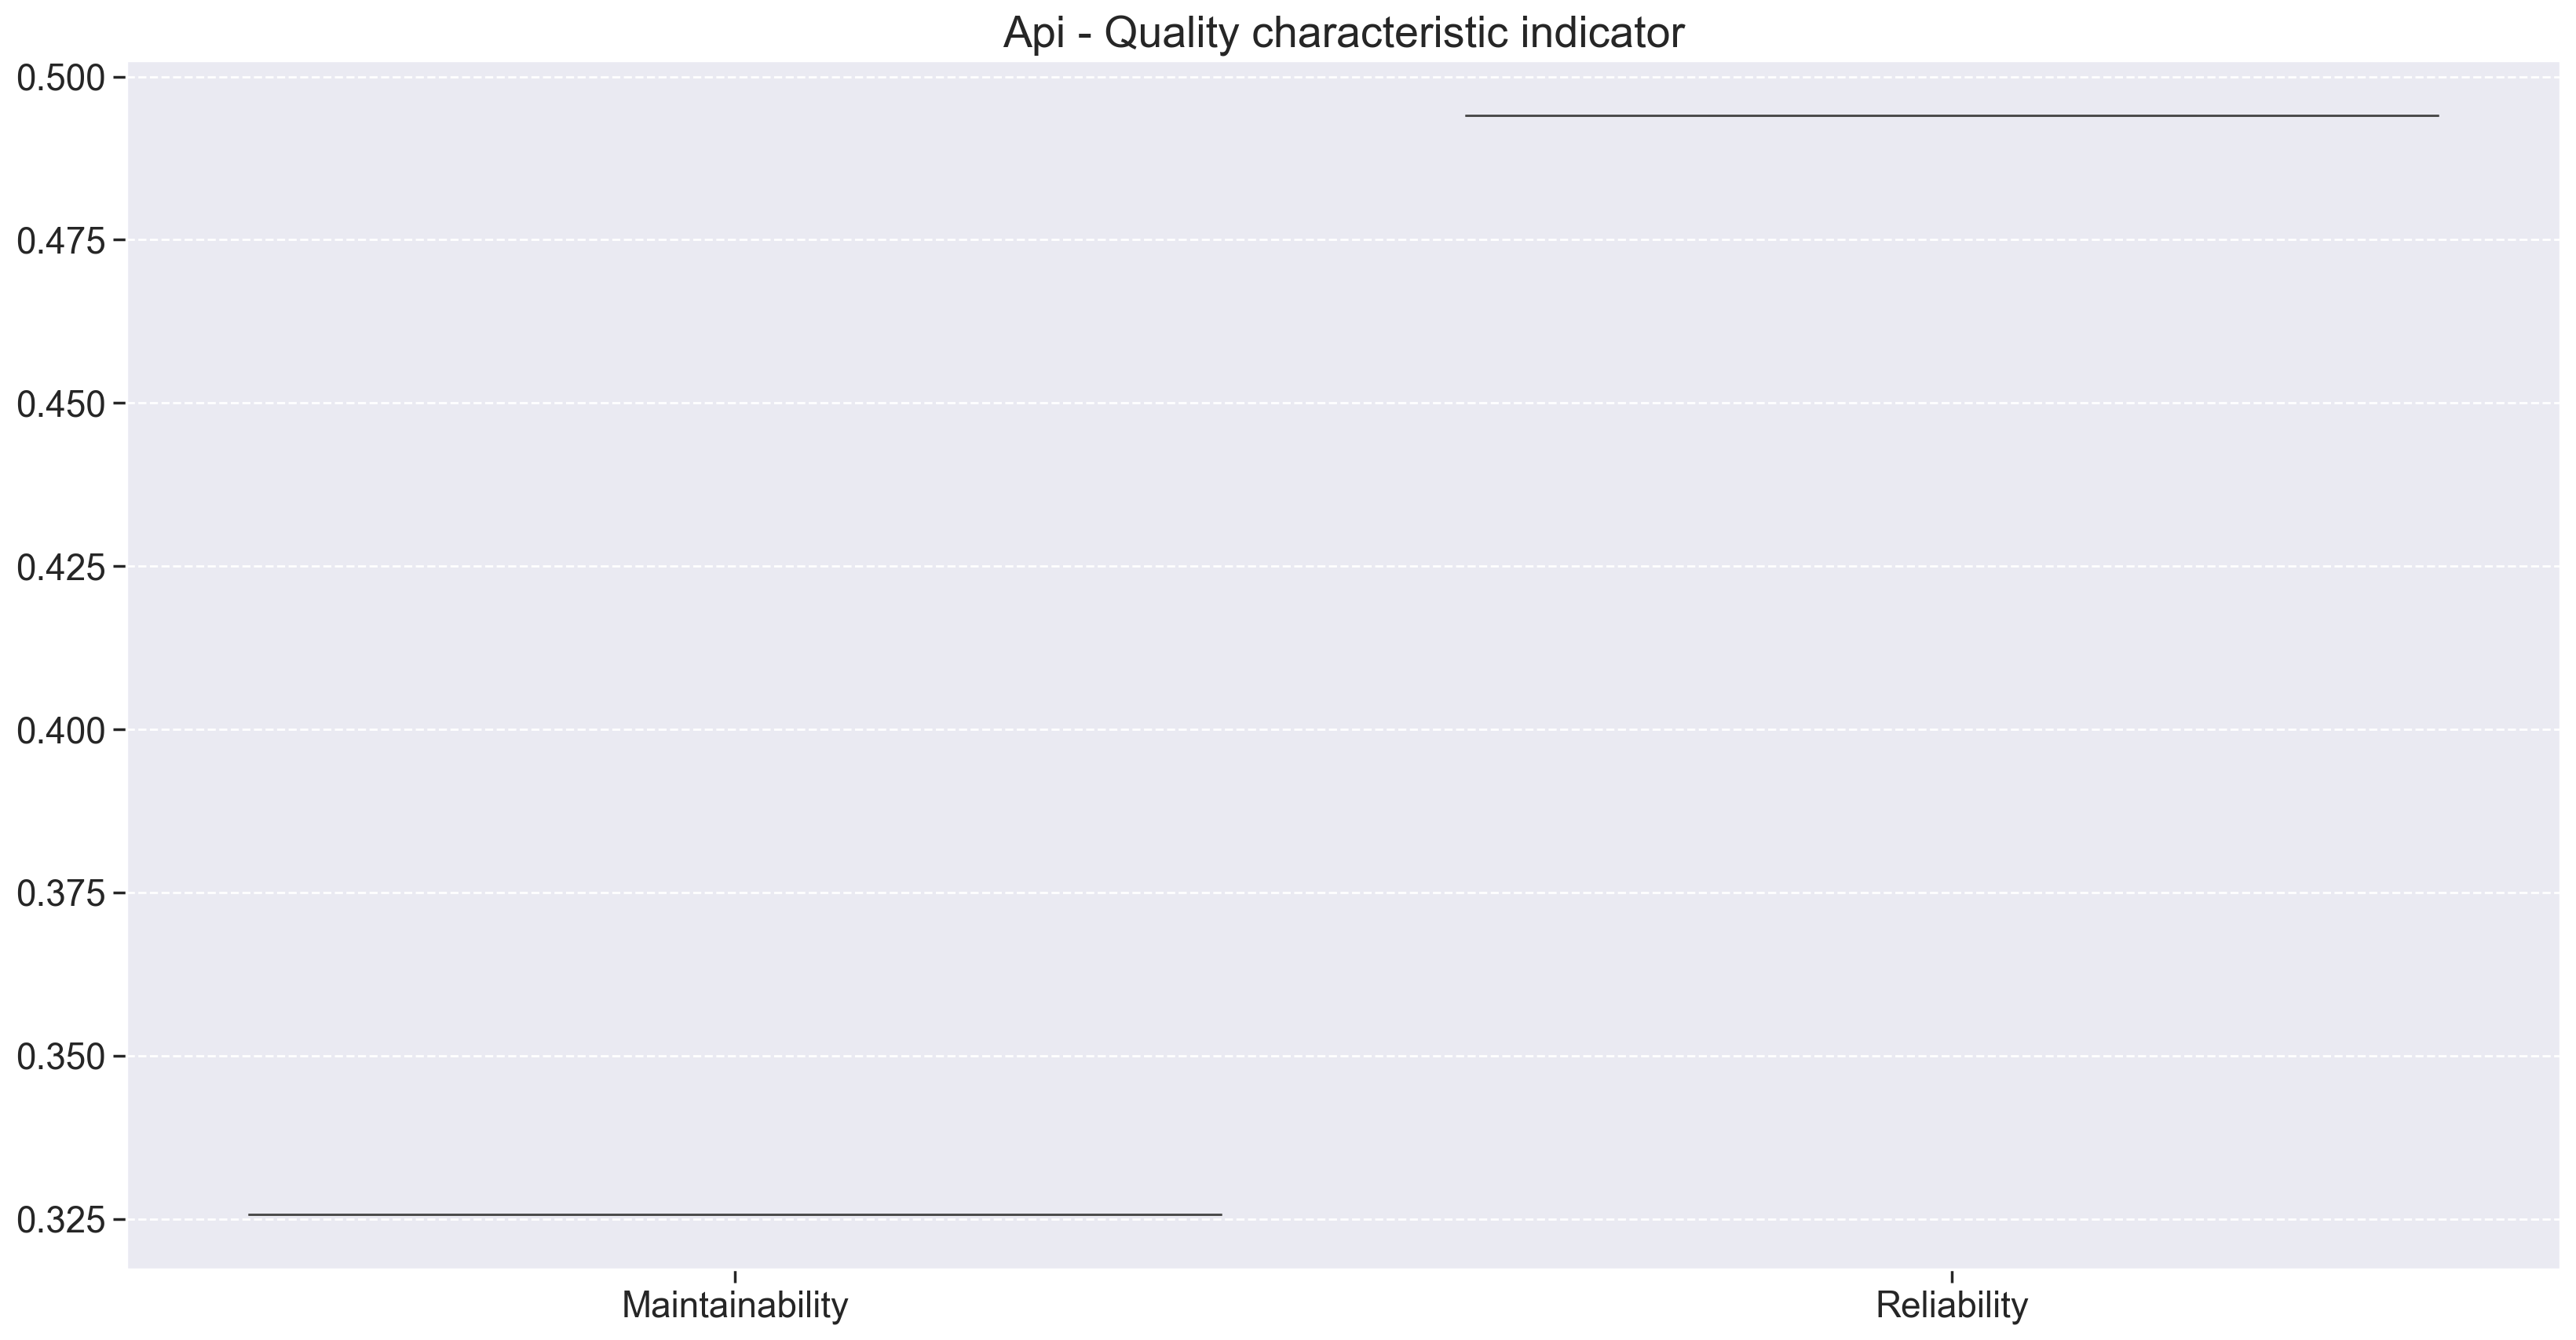

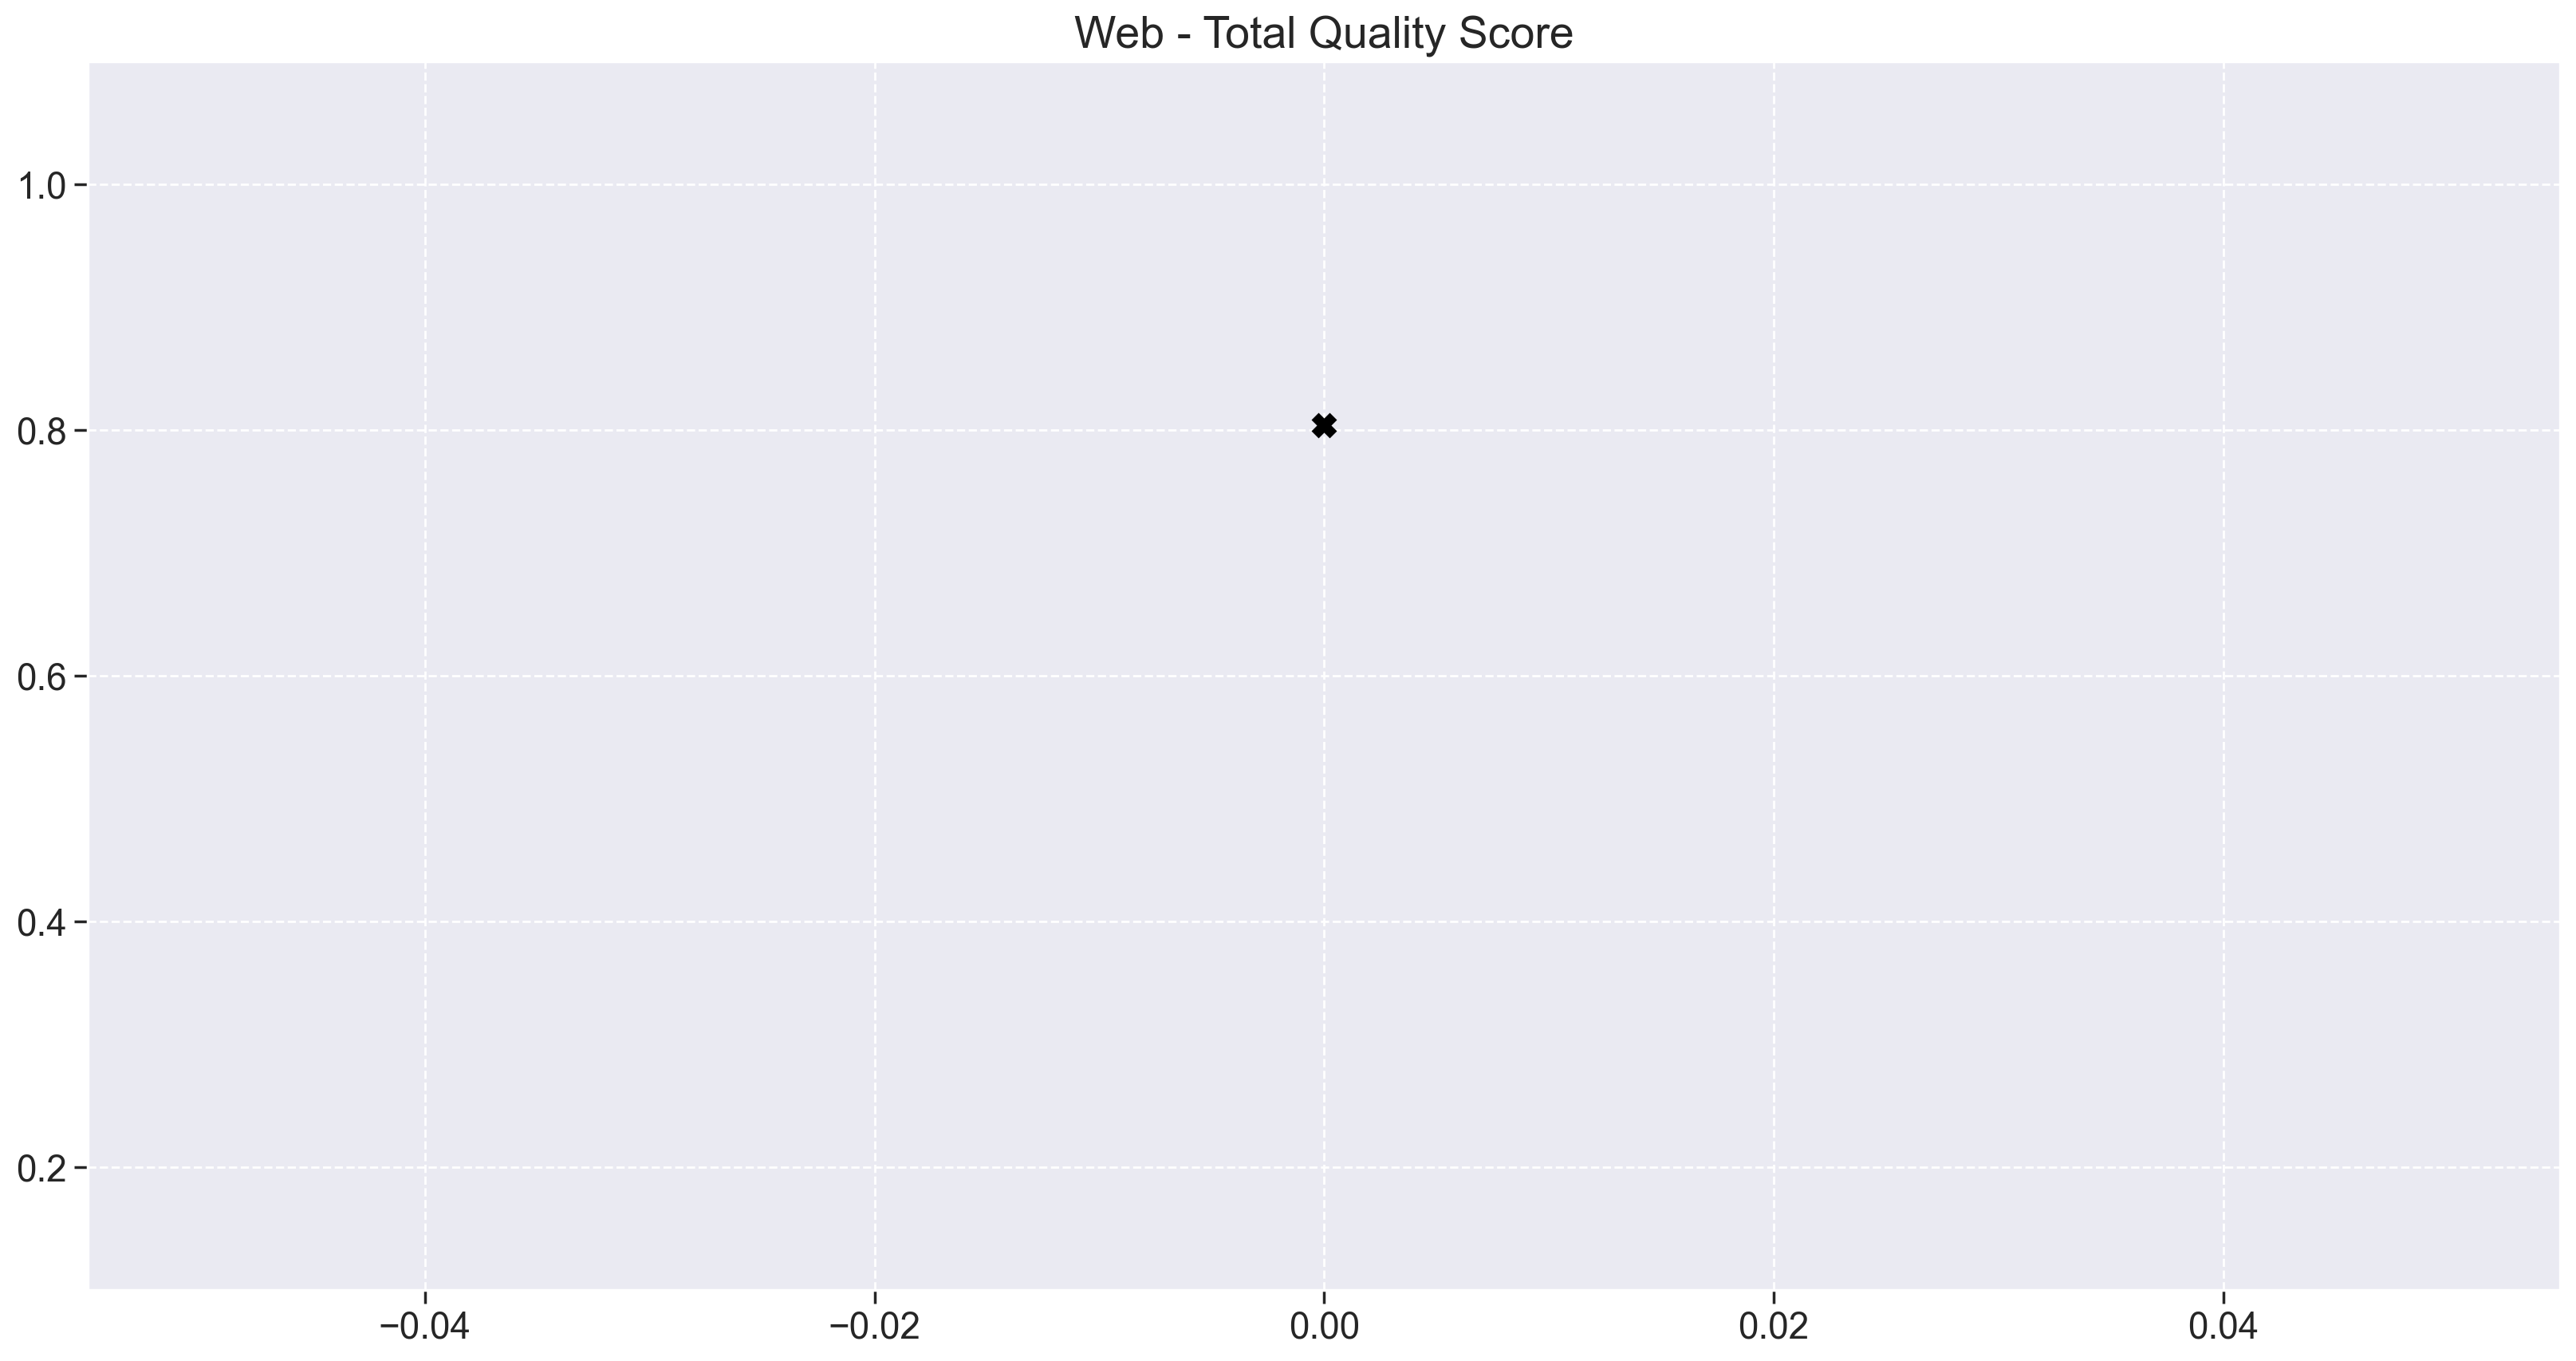

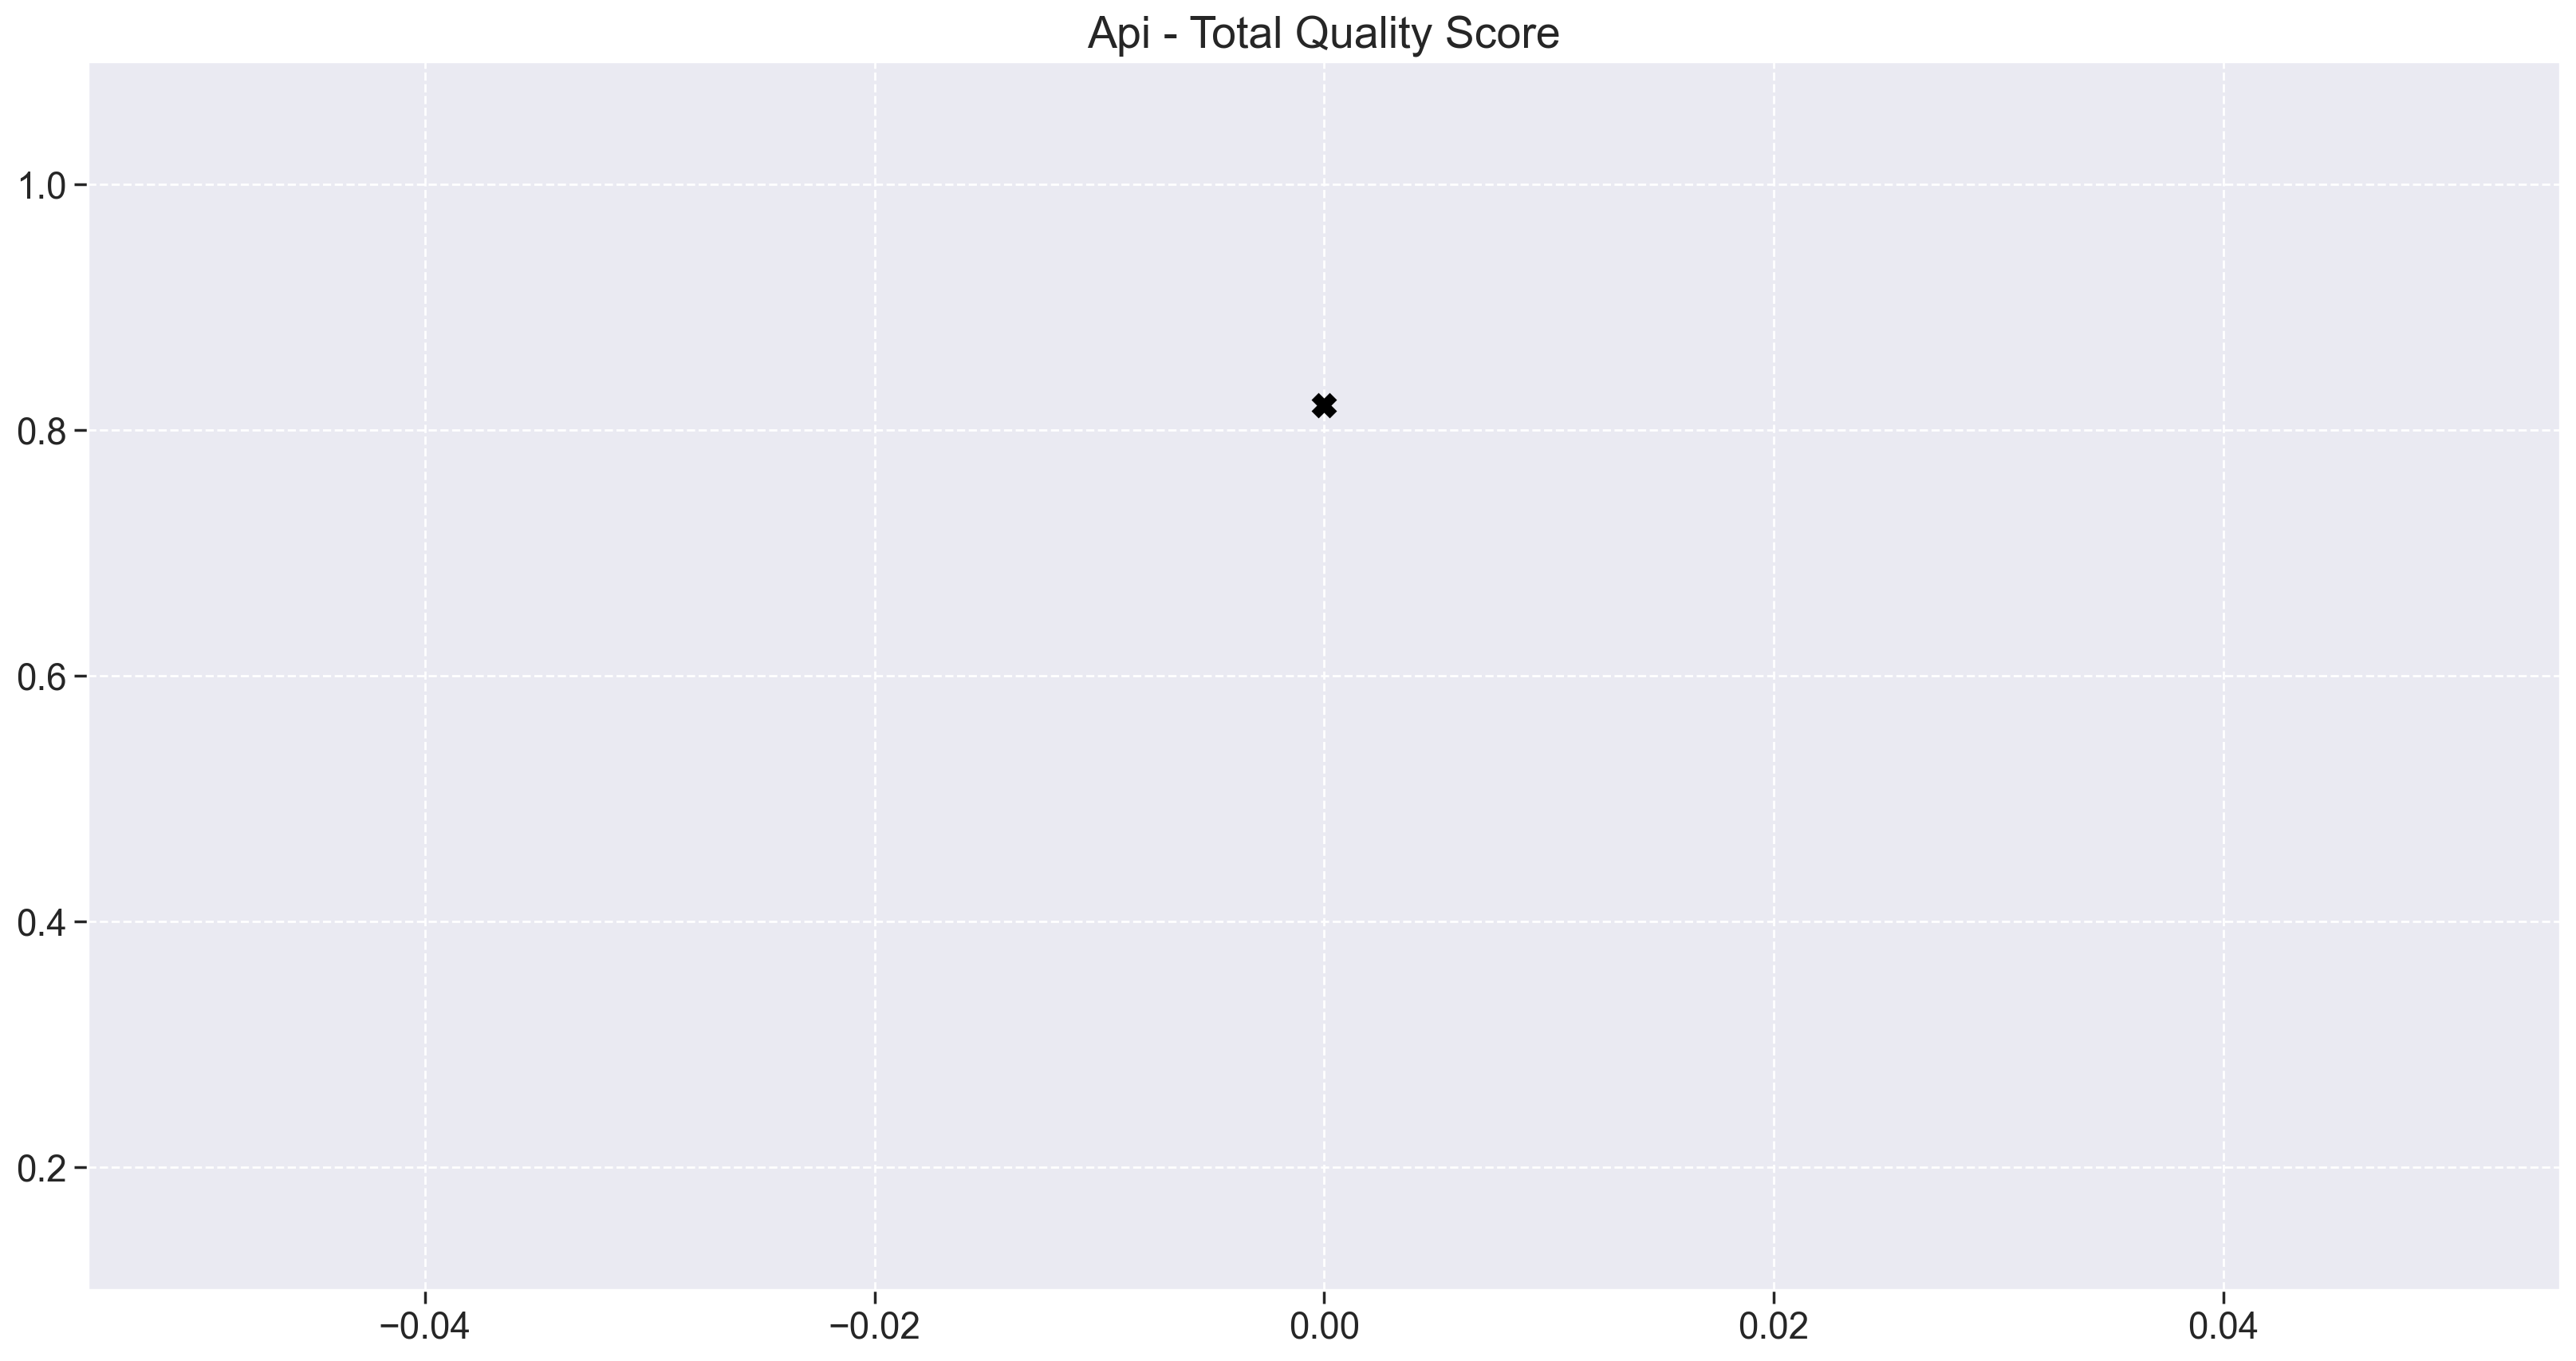

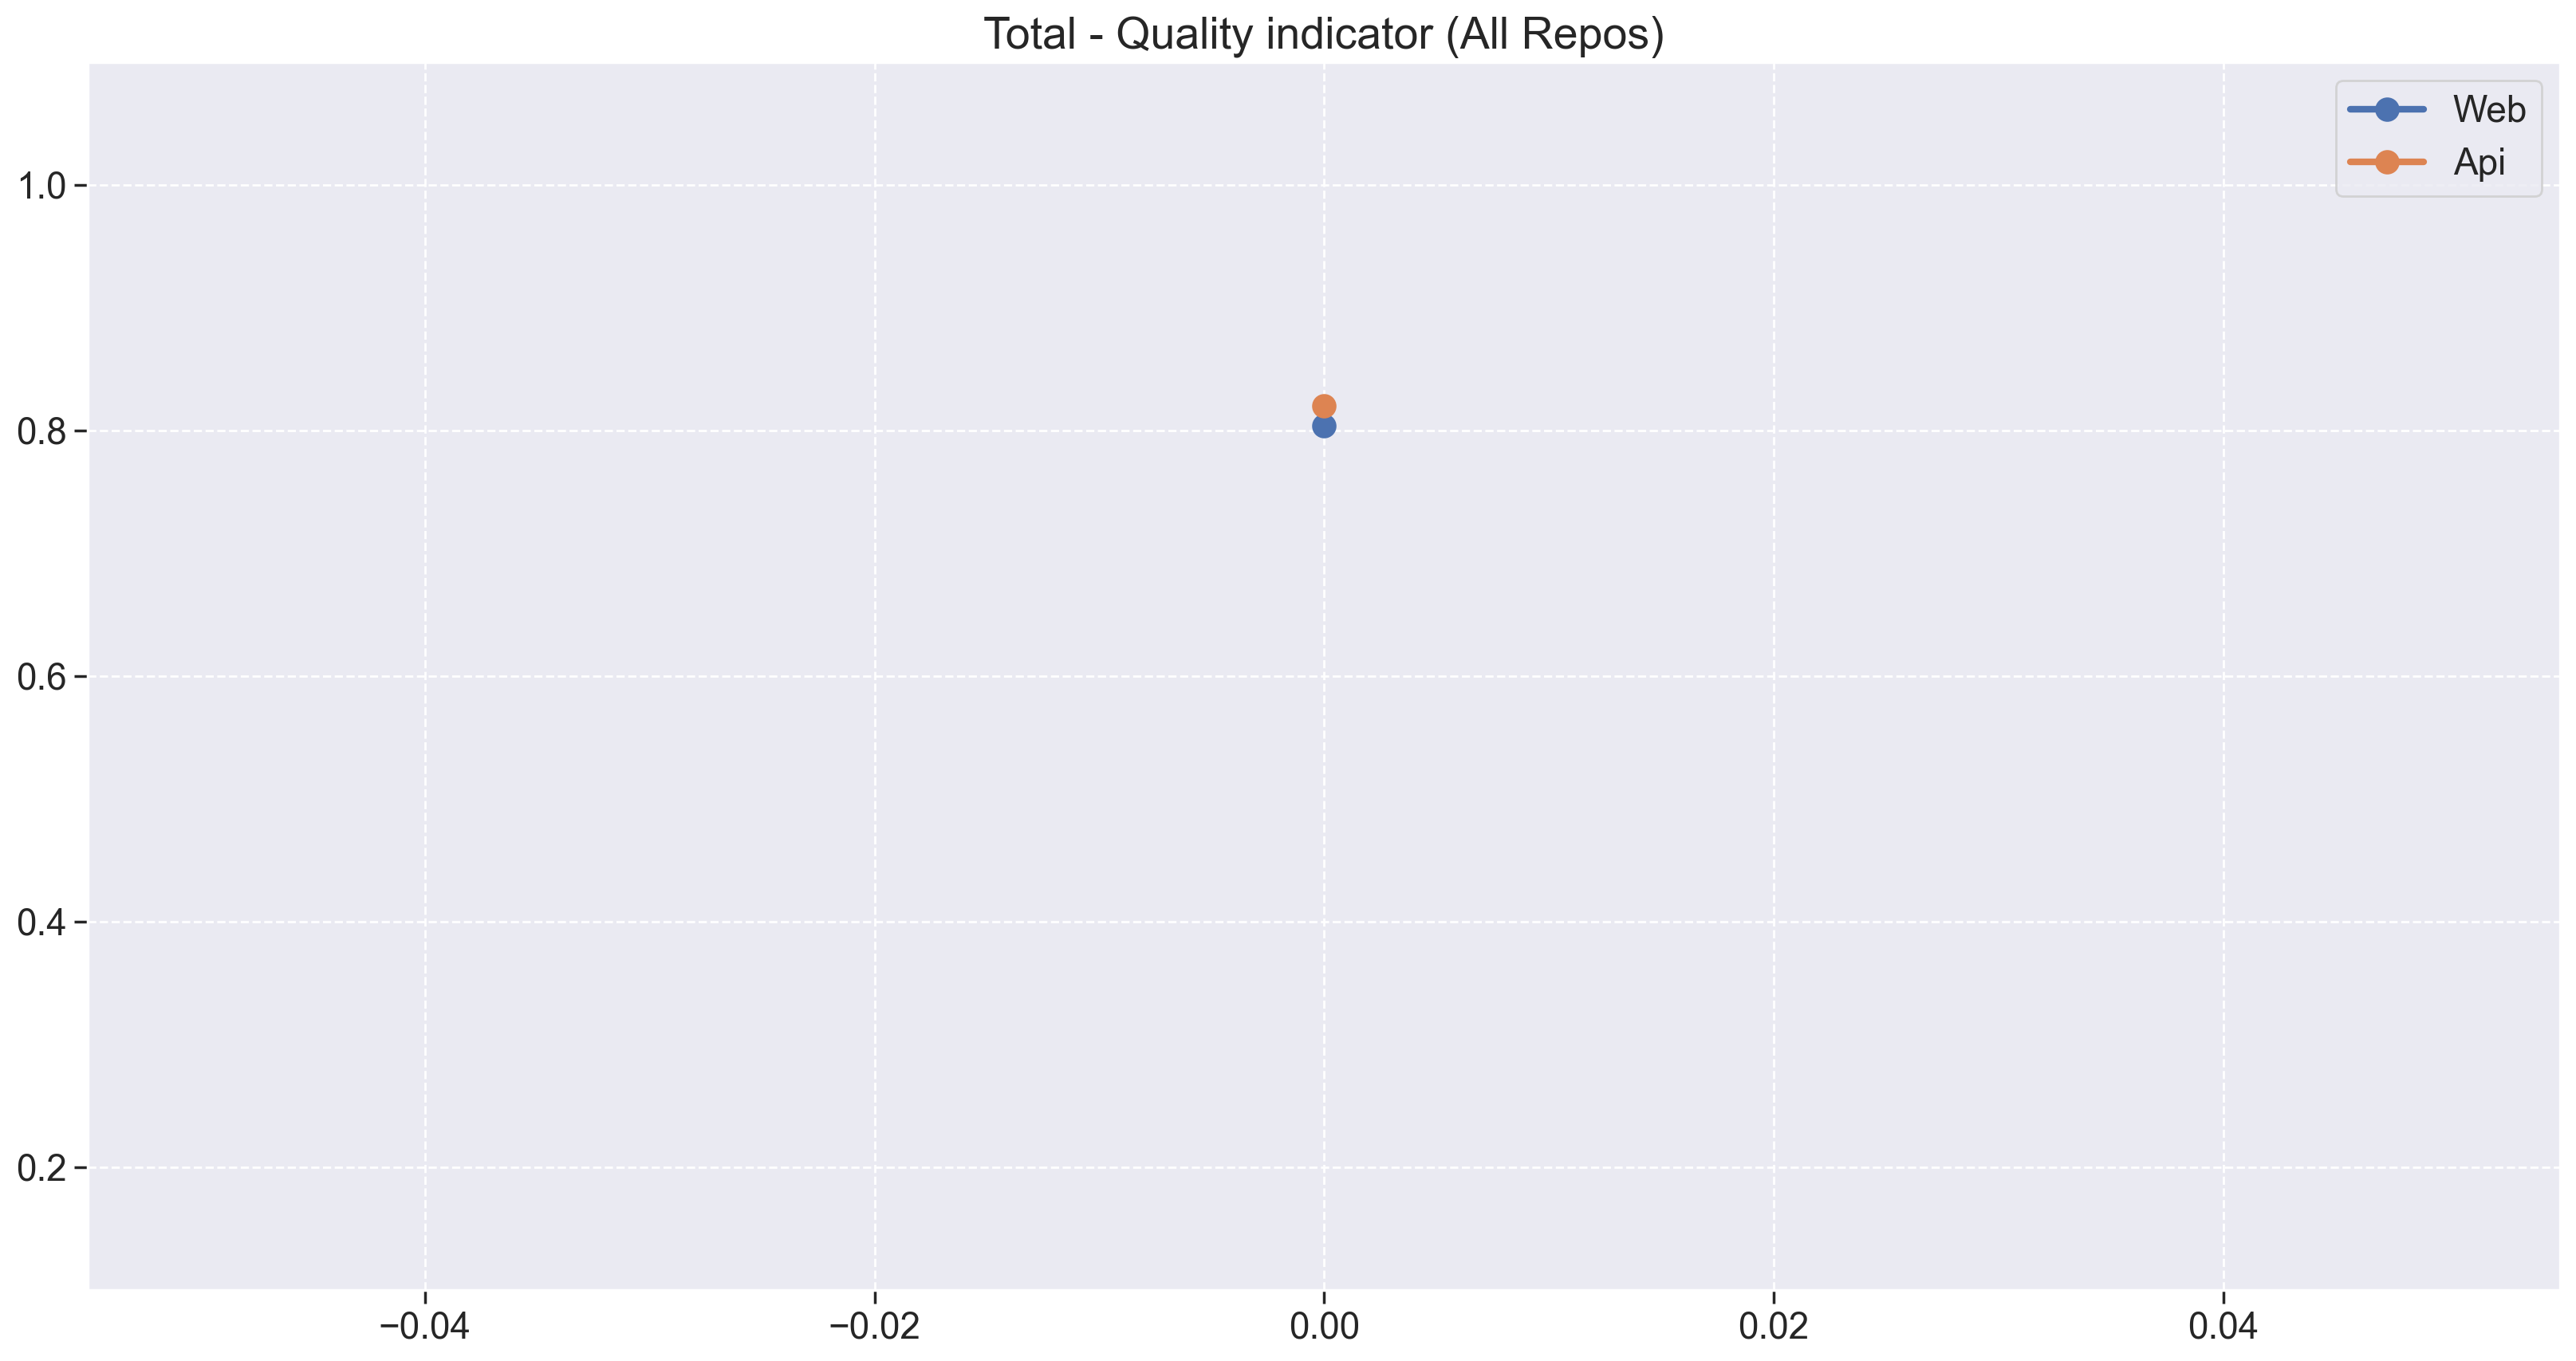

In [7]:
import pandas as pd
import json
from glob import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
import datetime

%matplotlib inline
%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.5)
sns.set_style('darkgrid', {'xtick.bottom' : True, 'ytick.left': True, 'grid.linestyle':'--'})

pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('future.no_silent_downcasting', True)

repo_name = 'fga-eps-mds-2026-1-RetinaScan-'
repos_language = {
    'Web': 'ts',
    'Api': 'ts',
}

sonar_files = glob('../analytics-raw-data/fga-eps-mds-*.json')

metric_list = ['files', 'functions', 'complexity', 'comment_lines_density', 
               'duplicated_lines_density', 'coverage', 'ncloc', 'tests', 
               'test_errors', 'test_failures', 'test_execution_time', 'security_rating']

def unmarshall(json_path: str) -> dict:
    with open(json_path, encoding='utf-8') as json_file:
        return json.load(json_file)

def get_files_df(df: pd.DataFrame) -> pd.DataFrame:
    files_df = df[df['qualifier'] == 'FIL']
    return files_df.dropna(subset=['functions', 'complexity', 'comment_lines_density', 'duplicated_lines_density', 'coverage'])

def get_dir_df(df: pd.DataFrame) -> pd.DataFrame:
    dirs = df[df["qualifier"] == "DIR"].copy()
    if dirs.empty: 
        return pd.Series(dtype=float)
    return dirs[['test_errors', 'test_failures']].sum()

def get_uts_df(df: pd.DataFrame) -> pd.DataFrame:
    uts_df = df[df['qualifier'] == 'UTS'].fillna(0)
    return uts_df.dropna(subset=['test_execution_time'])

def _ncloc(df: pd.DataFrame) -> int:
    return int(pd.to_numeric(df['ncloc'], errors='coerce').sum())

def complexity(df: pd.DataFrame):
    f_df = get_files_df(df)
    f_df = f_df[pd.to_numeric(f_df['functions'], errors='coerce') > 0].copy()
    if f_df.empty: return 0
    comp = pd.to_numeric(f_df['complexity'], errors='coerce')
    func = pd.to_numeric(f_df['functions'], errors='coerce')
    return len(f_df[(comp / func) < 10]) / len(f_df)

def comments(df: pd.DataFrame):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    dens = pd.to_numeric(f_df['comment_lines_density'], errors='coerce')
    return len(f_df[(dens > 10) & (dens < 30)]) / len(f_df)

def duplication(df: pd.DataFrame):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    dup = pd.to_numeric(f_df['duplicated_lines_density'], errors='coerce')
    return len(f_df[dup < 5]) / len(f_df)

def test_success(df: pd.DataFrame):
    uts_df = df[df['qualifier'] == 'UTS']
    if uts_df.empty: 
        return 0
    
    errors = uts_df.get('test_errors', pd.Series([0]*len(uts_df))).fillna(0)
    failures = uts_df.get('test_failures', pd.Series([0]*len(uts_df))).fillna(0)
    
    passed_tests = len(uts_df[(errors + failures) == 0])
    return passed_tests / len(uts_df)

def fast_tests(df: pd.DataFrame):
    uts_df = get_uts_df(df)
    if uts_df.empty: return 0
    fast = len(uts_df[pd.to_numeric(uts_df['test_execution_time'], errors='coerce') < 300000])
    return fast / len(uts_df)

def coverage(df: pd.DataFrame):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    cov = pd.to_numeric(f_df['coverage'], errors='coerce')
    return len(f_df[cov > 60]) / len(f_df)

def metric_per_file(json_dict: dict) -> List[dict]:
    file_json = []
    for component in json_dict.get('components', []):
        measures = {m['metric']: float(m.get('value', 0)) for m in component.get('measures', [])}
        
        component['measures_dict'] = measures 
        
        qualifier = component.get('qualifier')
        ncloc = measures.get('ncloc', 0)

        if (qualifier == 'FIL' and ncloc > 0) or qualifier in ['DIR', 'UTS']:
            file_json.append(component)
    return file_json

def generate_component_dataframe_data(metrics_list, file_component_data, language_extension):
    rows = []
    for file in file_component_data:
        measures = file.get('measures_dict', {})
        row = {m: measures.get(m, None) for m in metrics_list} 
        
        row.update({
            'qualifier': file.get('qualifier'),
            'language': file.get('language'),
            'path': file.get('path')
        })
        
        if file['qualifier'] == 'FIL':
            if file.get('language') == language_extension:
                rows.append(row)
        else:
            rows.append(row)
            
    return pd.DataFrame(rows)

def create_component_df(json_list):
    df_res = pd.DataFrame()
    for json_path in json_list:
        file_component = unmarshall(json_path)
        base_name = os.path.basename(json_path)
        parts = base_name.split("-")
        repo_key = parts[6] if len(parts) > 6 else None
        
        if repo_key and repo_key in repos_language:
            file_df = generate_component_dataframe_data(metric_list, metric_per_file(file_component), repos_language[repo_key])
            file_df['filename'] = base_name
            df_res = pd.concat([df_res, file_df], ignore_index=True)
            
    if df_res.empty: return df_res
            
    aux = df_res['filename'].str.split(r"-(\d+-\d+-\d+-\d+-\d+-\d+)-(.*?).json", expand=True)
    df_res['repository'], df_res['datetime_str'], df_res['version'] = aux[0], aux[1], aux[2]
    df_res['datetime'] = pd.to_datetime(df_res['datetime_str'], format='%Y-%m-%d-%H-%M-%S', errors='coerce')
    
    return df_res.sort_values(by=['repository', 'datetime'])

file_component_df = create_component_df(sonar_files)

repos_dataframes = []
if not file_component_df.empty:
    for repo in repos_language.keys():
        dataframe = file_component_df[file_component_df['repository'] == repo_name + repo]
        if not dataframe.empty:
            repos_dataframes.append({'name': repo, 'df': dataframe})

def create_metrics_df(df: pd.DataFrame) -> pd.DataFrame:
    res = []
    for v in df['datetime_str'].unique():
        v_df = df[df['datetime_str'] == v]
        res.append({
            'complexity': complexity(v_df), 'comments': comments(v_df), 'duplication': duplication(v_df),
            'test_success': test_success(v_df), 'fast_tests': fast_tests(v_df), 'coverage': coverage(v_df),
            'repository': v_df['repository'].iloc[0], 'version': v_df['version'].iloc[0], 
            'datetime': v_df['datetime'].iloc[0], 'ncloc': _ncloc(v_df)
        })
    return pd.DataFrame(res)

metrics = {r['name']: create_metrics_df(r['df']) for r in repos_dataframes}

for name, data in metrics.items():
    plt.figure(figsize=(20, 10))
    d = data.reset_index()
    plt.plot(d['complexity'], linewidth=3, marker='<', markersize=10, label="Complexity")
    plt.plot(d['comments'], linewidth=3, marker='s', markersize=10, label="Comments")
    plt.plot(d['duplication'], linewidth=3, marker='p', markersize=10, label="Duplication")
    plt.plot(d['test_success'], linewidth=3, marker='v', markersize=10, label="Passed Tests")
    plt.plot(d['fast_tests'], linewidth=3, marker='^', markersize=10, label="Fast Test Builds")
    plt.plot(d['coverage'], linewidth=3, marker='>', markersize=10, label="Coverage")
    plt.title(f"{name} - Base Metrics", fontsize=20); plt.legend(loc='best'); plt.show()

psc1, psc2, pc1, pc2 = 1, 1, 0.5, 0.5
pm1, pm2, pm3 = 0.33, 0.33, 0.33
pm4, pm5, pm6 = 0.25, 0.25, 0.50

for name, data in metrics.items():
    data['code_quality'] = ((data['complexity']*pm1) + (data['comments']*pm2) + (data['duplication']*pm3)) * psc1
    data['testing_status'] = ((data['test_success']*pm4) + (data['fast_tests']*pm5) + (data['coverage']*pm6)) * psc2
    data['Maintainability'] = data['code_quality'] * pc1
    data['Reliability'] = data['testing_status'] * pc2
    data['total'] = data['Maintainability'] + data['Reliability']

for name, data in metrics.items():
    plt.figure(figsize=(20, 10))
    sns.boxplot(data=data[['Maintainability','Reliability']])
    plt.title(f"{name} - Quality characteristic indicator", fontsize=20); plt.show()

def get_stats(repo_series):
    return {'mean': [repo_series.mean()], 'mode': [repo_series.mode()[0] if not repo_series.mode().empty else 0],
            'median': [repo_series.median()], 'std': [repo_series.std()], 'var': [repo_series.var()],
            'min': [repo_series.min()], 'max': [repo_series.max()]}

for name, data in metrics.items():
    d = data.reset_index()
    plt.figure(figsize=(20, 10))
    plt.plot(d['total'], linewidth=3, marker='X', markersize=10, color='black')
    plt.ylim(0.1, 1.1); plt.title(f'{name} - Total Quality Score', fontsize=20); plt.show()

plt.figure(figsize=(20, 10))
for name, data in metrics.items():
    plt.plot(data.reset_index()['total'], linewidth=3, marker='o', markersize=10, label=name)
plt.ylim(.1, 1.1); plt.title("Total - Quality indicator (All Repos)", fontsize=20); plt.legend(); plt.show()

if metrics:
    if not os.path.exists('./data'): os.makedirs('./data')
    metrics_df = pd.concat(metrics.values(), ignore_index=True)
    curr_time = datetime.datetime.now().strftime("%m-%d-%Y--%H-%M-%S")
    fn = f"./data/{repo_name}{curr_time}"
    
    metrics_df.to_csv(f"{fn}.csv", index=False)
    try:
        metrics_df.to_excel(f"{fn}.xlsx", index=False)
    except ModuleNotFoundError:
        print(f"\n[AVISO] CSV gerado em: {fn}.csv. (Instale 'openpyxl' para exportar Excel)")

# Analytics - Product Quality - GitHub
Date: 2026/04  
Summary: Este notebook representa a análise de produtividade e saúde do workflow de desenvolvimento do projeto RetinaScan, utilizando dados extraídos da API do GitHub.

---

## Equipe
* Semester: 2026/01
* Professor: Hilmer Neri
* Membros: - Natália Morais 
           - André Maia
           - Arthur Ribeiro
           - Cecília Quaresma
           - Elias Oliveira
           - Eric Camargo
           - Gustavo Costa
           - Harleny Angelica
           - Iderlan Junio
           - Vinicius Roriz
           - Yan Luca
           - Zenilda Vieira

---

## Metodologia e Coleta de Dados

A análise processa dados brutos (arquivos JSON) obtidos via integração com a API do GitHub, focando em dois eixos principais:
1. Workflow Runs: Dados de execução das Actions (CI/CD) para medir tempo de resposta e taxa de sucesso.
2. Issues: Monitoramento do volume de demandas criadas e finalizadas para medir a vazão da equipe.

O processamento garante a normalização de datas e o cálculo automático do **Feedback Time** (diferença entre o início da execução e a última atualização do status do workflow).

---

## Indicadores de Produtividade (Productivity)

Seguindo o modelo de análise, os dados são agrupados em dois fatores principais:

### 1. Factor: Testing Performance (CI Feedback)
Focado na eficiência das ferramentas de Integração Contínua:
* CI Feedback Time: Mede o tempo médio que o desenvolvedor precisa esperar para obter uma resposta do workflow de build (`code-analysis`). Um tempo alto indica gargalos no pipeline.
* Success vs Failure Rate: Porcentagem de execuções que terminaram em sucesso comparadas às falhas, indicando a estabilidade do código no repositório.

### 2. Factor: Issues' Velocity (Team Throughput)
Mede a capacidade de entrega da equipe em um intervalo de tempo:
* Throughput: É a densidade de Issues fechadas em relação ao total de Issues abertas no período. 
* Cálculo: Considera a janela temporal entre `start_date_issues` e `end_date_issues`.

---

## Visualizações Geradas

O notebook automatiza a geração de gráficos para os repositórios Web e Api:

1.  CI Feedback Time By Creation Date: Gráfico de linha que mostra a oscilação do tempo de build ao longo dos dias.
2.  Workflows Success vs Failures: Gráfico de pizza que ilustra a integridade do processo de build.
3. Team Throughput (Issues Density): Gráfico de pizza consolidado que mostra a eficiência da equipe na resolução de tarefas/bugs.
4. Team Velocity Bar Chart: Histograma semanal que mostra a constância das entregas da equipe.
5. Project Burndown: Comparativo entre o planejado (Ideal Burn) e o executado (Real Burn), permitindo prever atrasos.

---

## Exportação e Filtros
A análise permite o ajuste dinâmico de datas para auditorias específicas de sprints ou marcos do projeto:
* Workflow Runs Range: `2026-03-30` a `2026-04-27`
* Issues Range: `2026-03-30` a `2026-04-27`

Os dados tratados são estruturados em DataFrames do Pandas para facilitar a exportação caso seja necessária uma análise externa adicional.

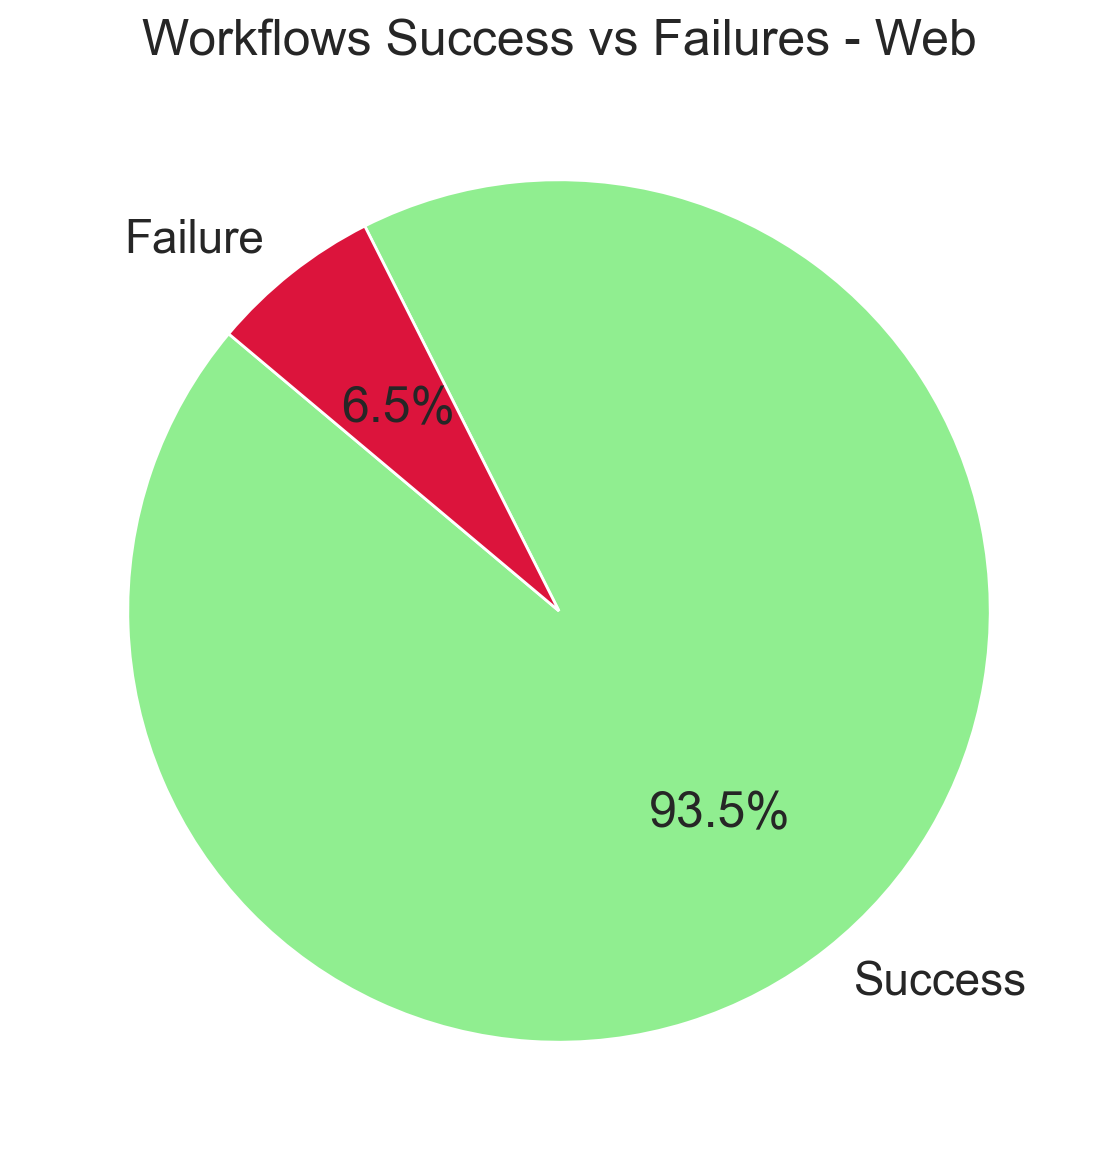

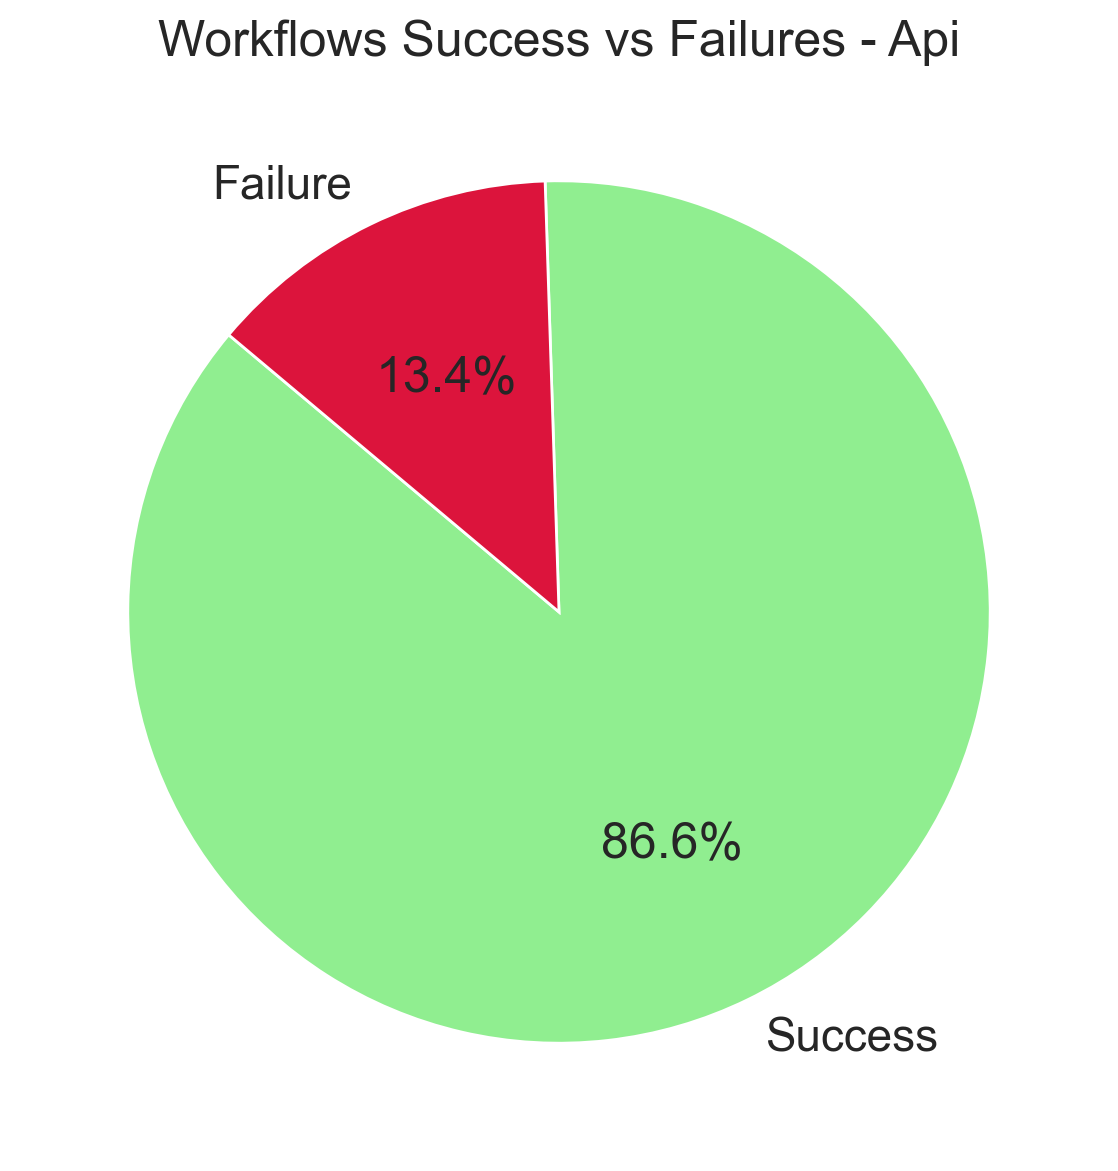

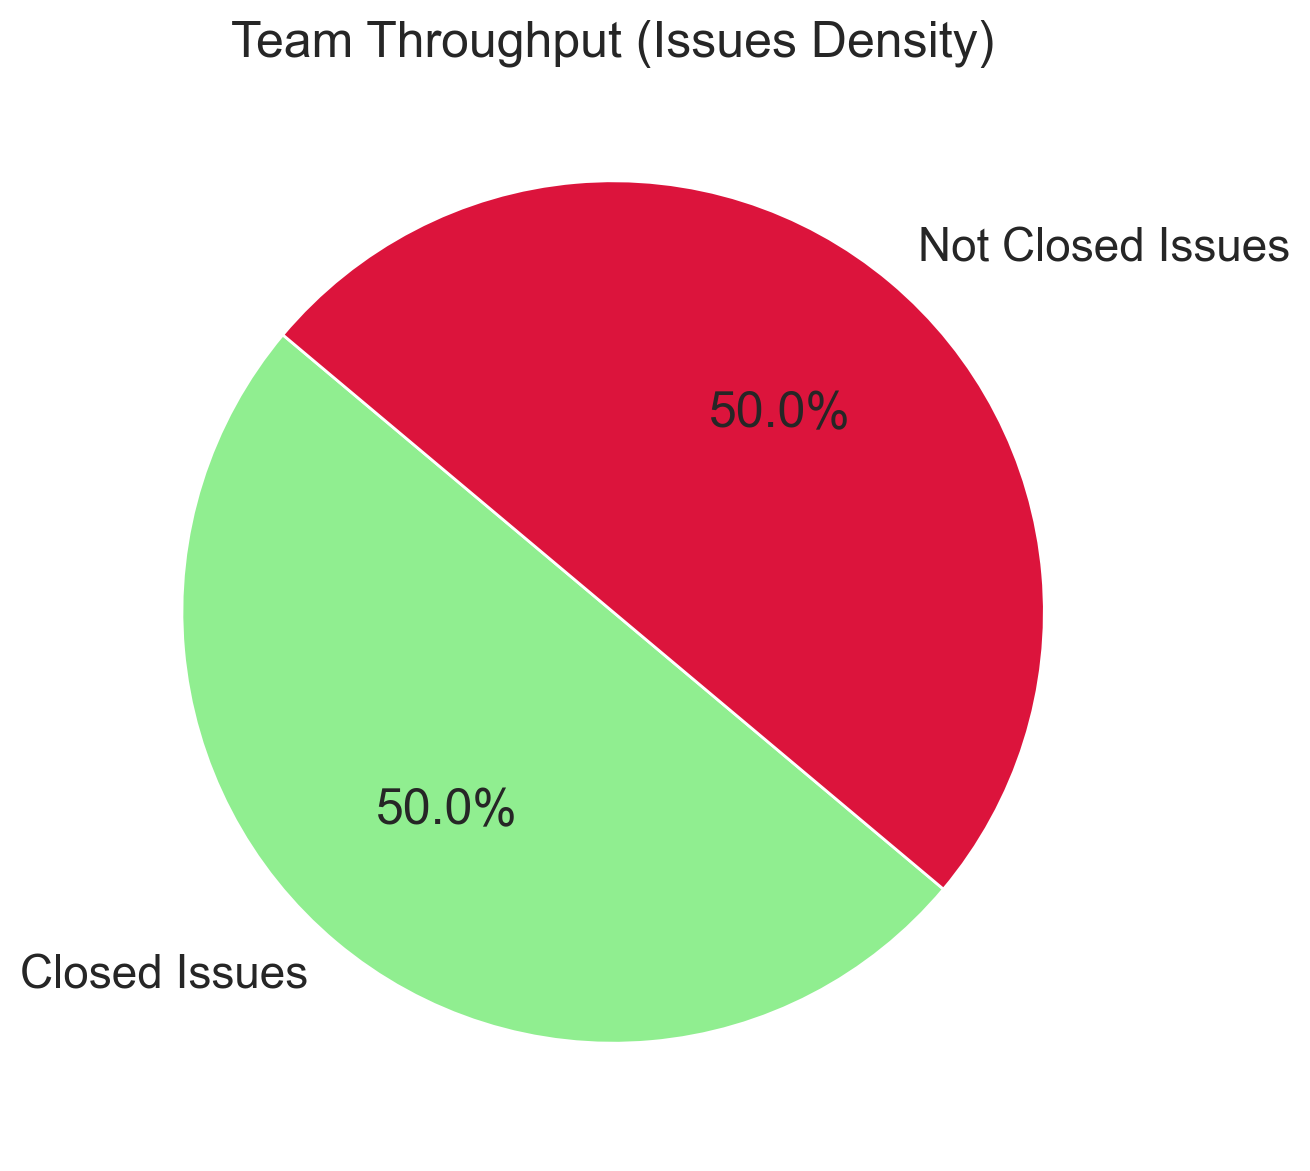

In [8]:
import pandas as pd
import json
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os

%matplotlib inline
%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.5)
sns.set_style('darkgrid', {'xtick.bottom' : True, 'ytick.left': True, 'grid.linestyle':'--'})

repo_base_name = 'fga-eps-mds-2026-1-RetinaScan-'
repos_project = ['Web', 'Api']
build_yml_name = "code-analysis" 

start_date_workflow_runs = "2026-03-30"
end_date_workflow_runs = "2026-04-27"
start_date_issues = "2026-03-30"
end_date_issues = "2026-04-27"

def unmarshall(json_path: str) -> dict:
    with open(json_path, encoding='utf-8') as json_file:
        return json.load(json_file)

def get_workflow_data():
    data_runs = glob(f'../analytics-raw-data/GitHub_API-Runs-{repo_base_name}*.json')
    table_data = []
    for json_path in data_runs:
        dados = unmarshall(json_path)
        for run in dados.get("workflow_runs", []):
            repo_id = "Web" if "Web" in json_path else "Api"
            
            created_at = pd.to_datetime(run["created_at"]).tz_localize(None)
            updated_at = pd.to_datetime(run["updated_at"]).tz_localize(None)
            
            table_data.append({
                "Workflow_run ID": run["id"],
                "Conclusion": run["conclusion"],
                "Author": run["actor"]["login"],
                "Created at": created_at,
                "Updated at": updated_at,
                "Feedback Time": (updated_at - created_at).total_seconds(),
                "Workflow .YML Name": run["path"].split("/")[-1][:-4] if "/" in run["path"] else run["path"],
                "Repository Name": repo_id
            })
    return table_data

def get_issues_data():
    data_issues_files = glob(f'../analytics-raw-data/GitHub_API-Issues-{repo_base_name}*.json')
    table_data = []
    for json_path in data_issues_files:
        dados = unmarshall(json_path)
        if isinstance(dados, list):
            for issue in dados:
                table_data.append({
                    "Created at": pd.to_datetime(issue["created_at"]).tz_localize(None),
                    "Closed at": pd.to_datetime(issue["closed_at"]).tz_localize(None) if issue["closed_at"] else None,
                    "Issue Number": issue["number"],
                    "Issue Title": issue["title"],
                })
    return pd.DataFrame(table_data)

def ci_feedback_time(df: pd.DataFrame):
    df_filtered = df[df["Workflow .YML Name"] == build_yml_name].copy()
    if df_filtered.empty: return df_filtered
    df_filtered.loc[:, "Ci Feedback Time"] = df_filtered["Feedback Time"]
    return df_filtered

def count_success_failure_workflow_runs(df: pd.DataFrame):
    counts = df['Conclusion'].value_counts()
    return counts.get('failure', 0), counts.get('success', 0)

def team_throughput(df: pd.DataFrame, start_date: str, end_date: str):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date) + pd.Timedelta(days=1)
    
    df_date_filtered = df[(df['Created at'] >= start) & (df['Closed at'] <= end)]
    df_created = df[(df['Created at'] >= start) & (df['Created at'] <= end)]
    
    return len(df_date_filtered[df_date_filtered["Closed at"].notnull()]), len(df_created)

def ci_feedback_time_plots(df: pd.DataFrame, repo_name: str):
    if df.empty: return
    temp = df[['Created at', 'Ci Feedback Time']].copy()
    temp = temp.sort_values('Created at')
    dates = temp.groupby(temp['Created at'].dt.date).mean().reset_index()
    
    plt.figure(figsize=(15, 7))
    plt.plot(range(len(dates)), dates['Ci Feedback Time'], marker='o', linewidth=3, color='b', label='Feedback Time Mean')
    plt.xlabel("Creation Date")
    plt.ylabel("CI FeedBack Time (s)")
    plt.title(f"CI FeedBack Time By Creation Date - {repo_name}")
    plt.xticks(range(len(dates)), dates['Created at'], rotation=45)
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.show()

def count_sucess_failure_workflow_plot(data: list, repo_name: str):
    labels = ["Success", "Failure"]
    sizes = [data[1], data[0]] 
    if sum(sizes) == 0: return
    
    plt.figure(figsize=(15, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightgreen', 'crimson'], startangle=140)
    plt.title(f"Workflows Success vs Failures - {repo_name}")
    plt.show()

def team_throughput_plot(data: list):
    closed, total = data
    not_closed = max(total - closed, 0)
    
    labels = ["Closed Issues", "Not Closed Issues"]
    sizes = [closed, not_closed]
    
    if sum(sizes) == 0: 
        print("Aviso: Sem issues no período para Throughput Plot.")
        return

    plt.figure(figsize=(15, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightgreen', 'crimson'], startangle=140)
    plt.title("Team Throughput (Issues Density)")
    plt.show()

workflow_run_raw = get_workflow_data()
workflow_run_df = pd.DataFrame(workflow_run_raw)
issues_df = get_issues_data()

m1_list, m2_list, repository_list = [], [], []

for repo_key in repos_project:
    df_repo = workflow_run_df[workflow_run_df['Repository Name'] == repo_key]
    
    start_w = pd.to_datetime(start_date_workflow_runs)
    end_w = pd.to_datetime(end_date_workflow_runs) + pd.Timedelta(days=1)
    
    df_f = df_repo[(df_repo['Updated at'] >= start_w) & (df_repo['Updated at'] <= end_w)]
    
    if not df_f.empty:
        m1_list.append(ci_feedback_time(df_f))
        m2_list.append(count_success_failure_workflow_runs(df_f))
        repository_list.append(repo_key)

for i in range(len(repository_list)):
    ci_feedback_time_plots(m1_list[i], repository_list[i])
    count_sucess_failure_workflow_plot(m2_list[i], repository_list[i])

throughput_data = team_throughput(issues_df, start_date_issues, end_date_issues)
team_throughput_plot(throughput_data)

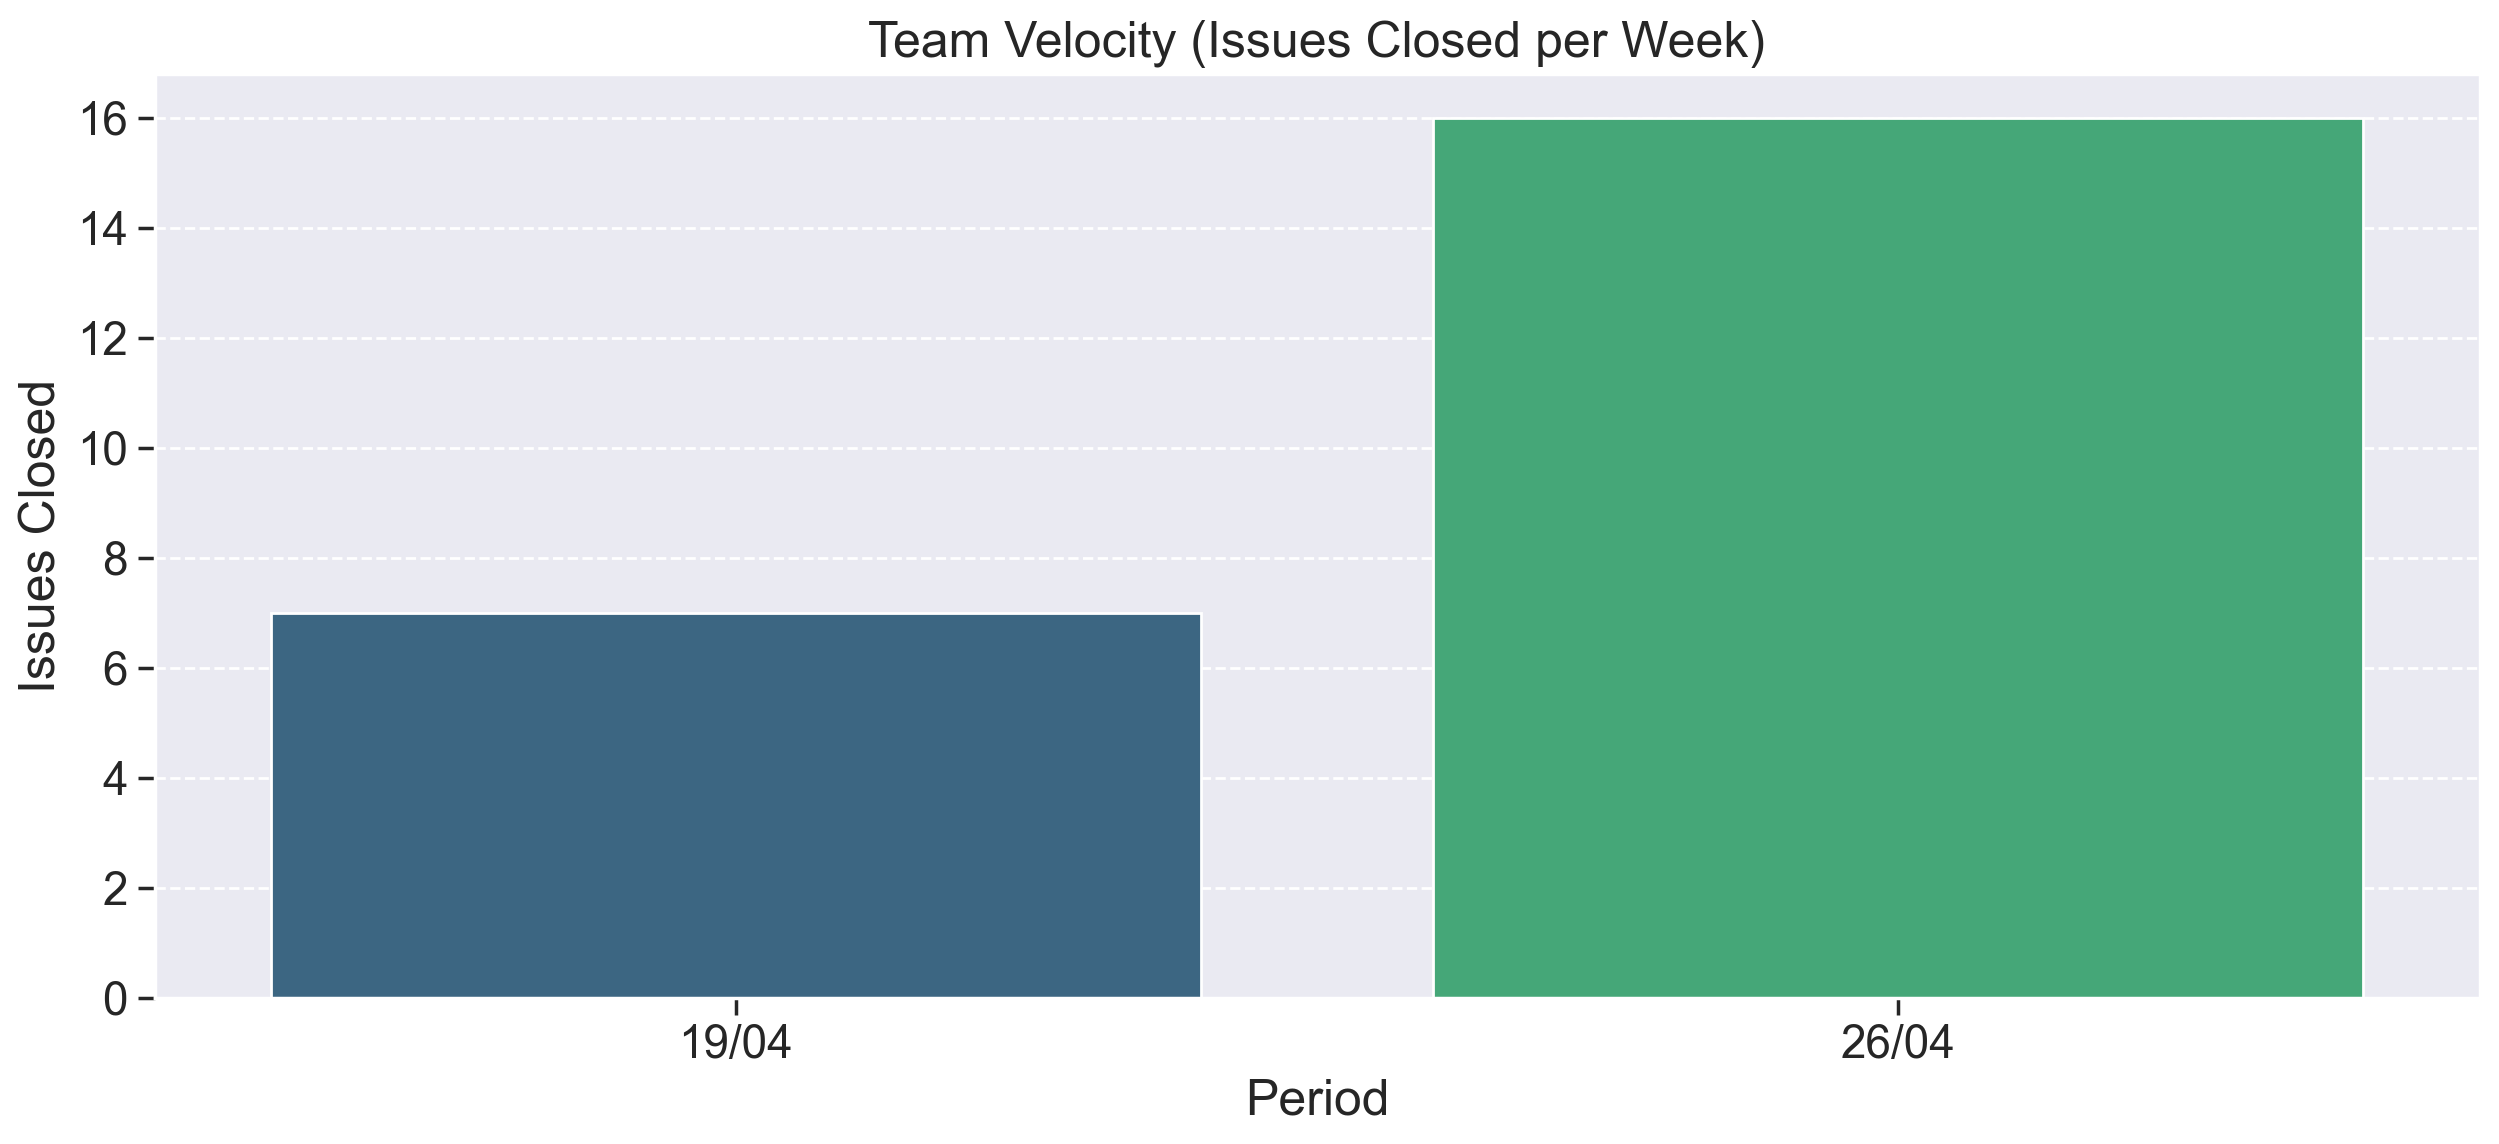

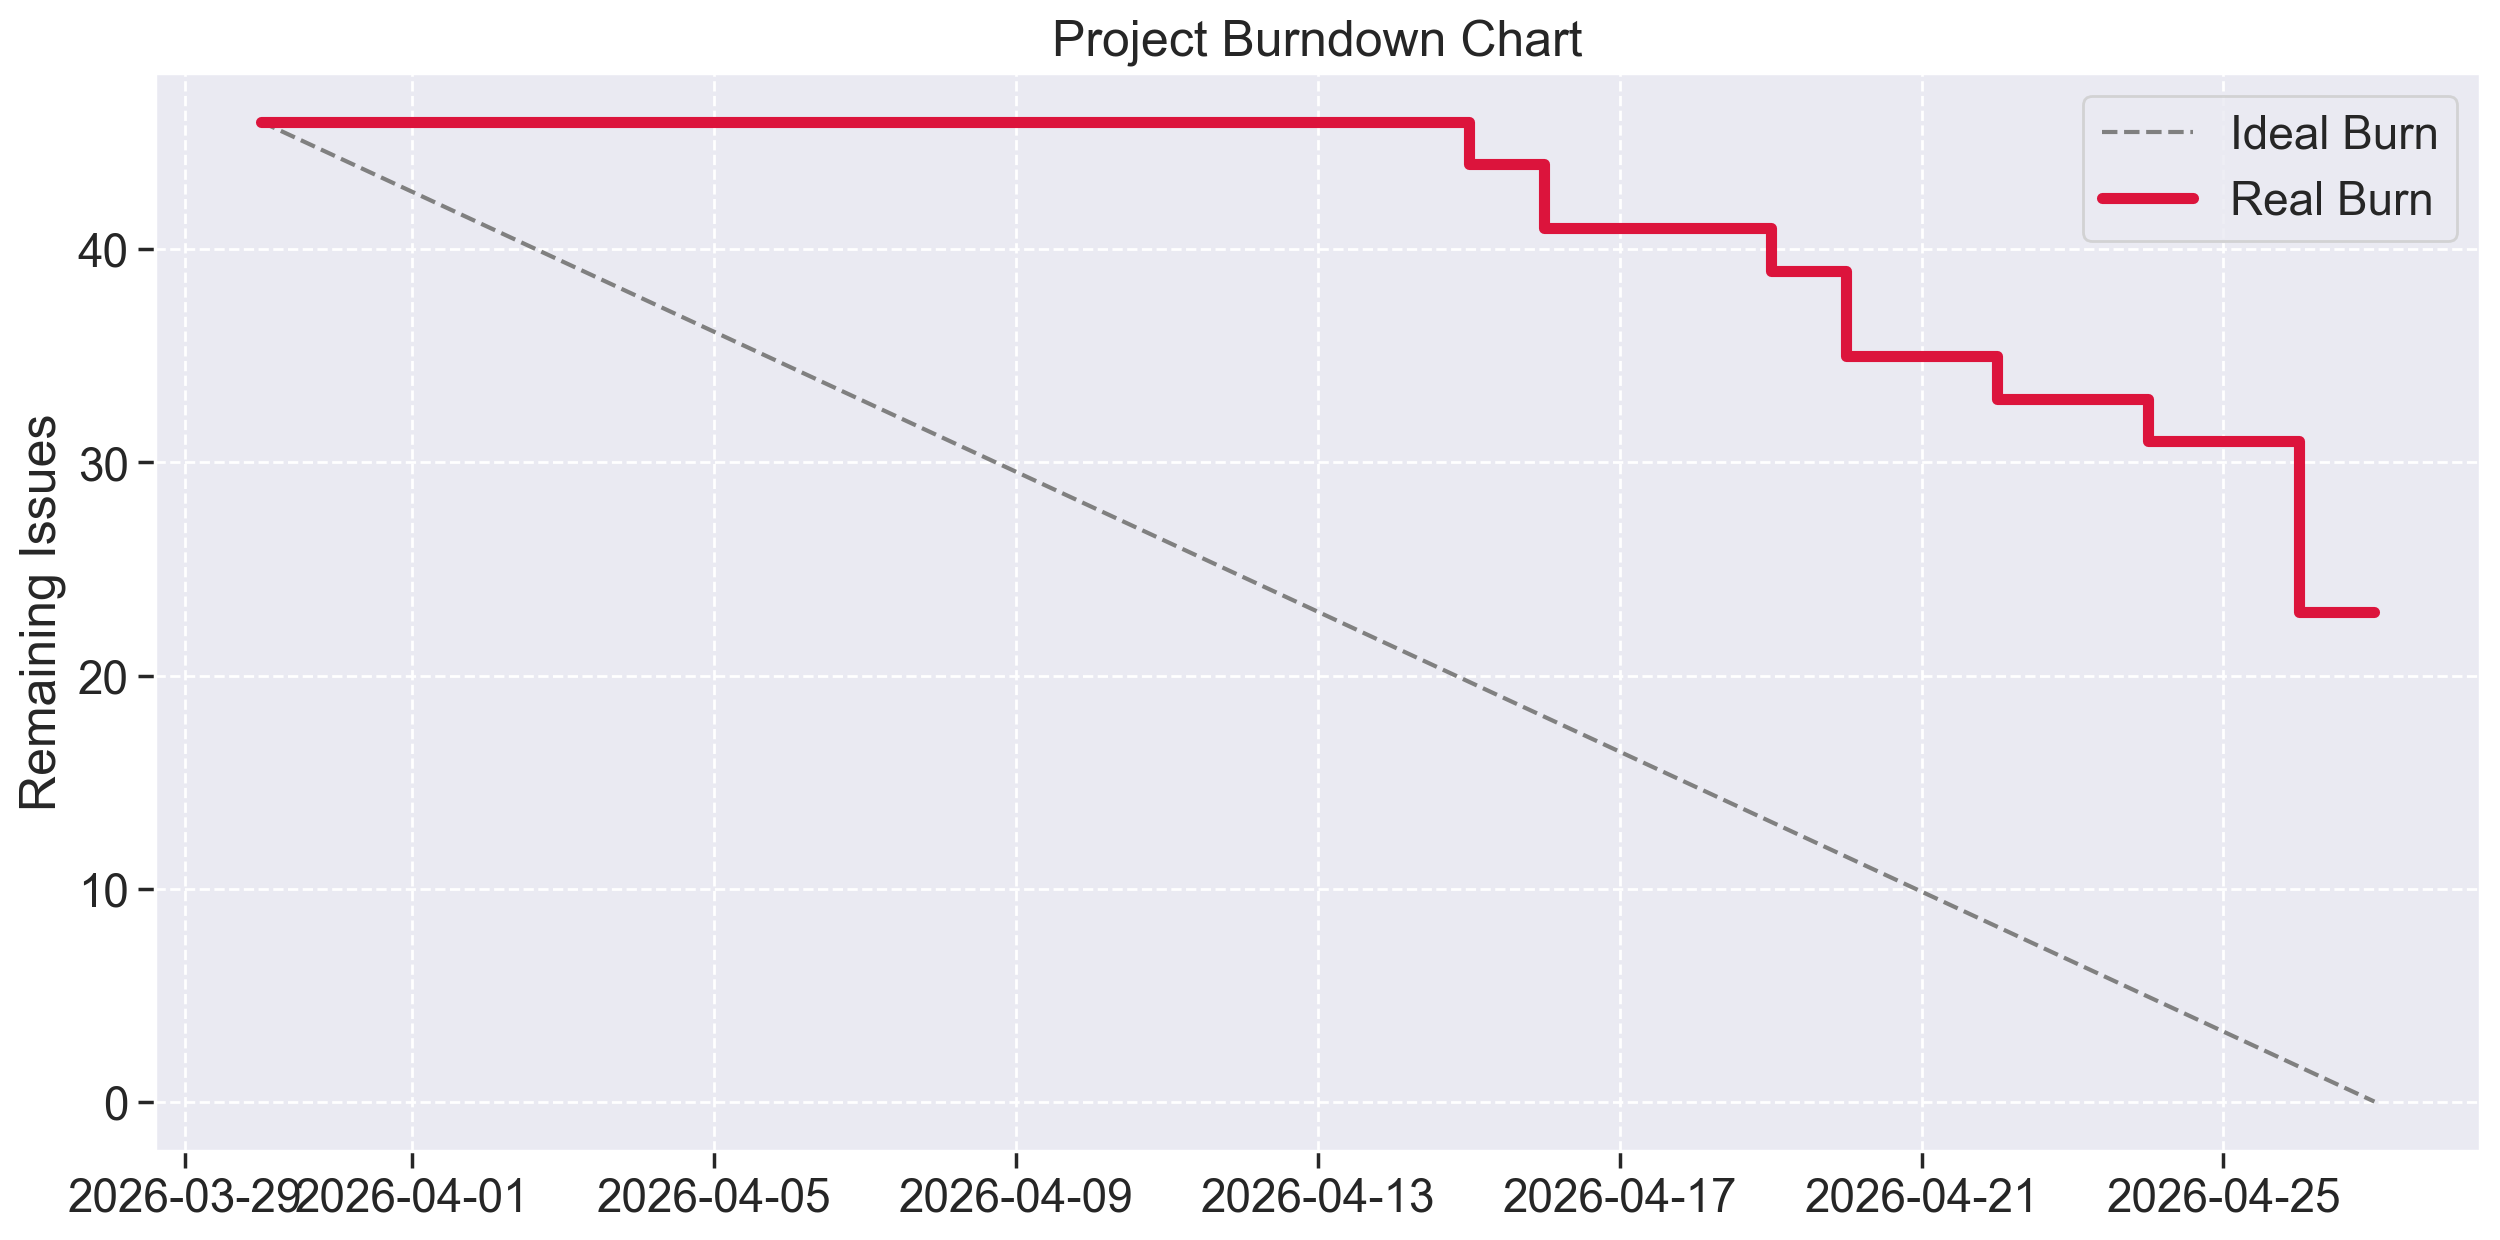

In [ ]:
import pandas as pd
import json
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.5)
sns.set_style('darkgrid', {'xtick.bottom' : True, 'ytick.left': True, 'grid.linestyle':'--'})

repo_base_name = 'fga-eps-mds-2026-1-RetinaScan-'
repos_project = ['Web', 'Api']
build_yml_name = "code-analysis" 

start_date_workflow_runs = "2026-03-30"
end_date_workflow_runs = "2026-04-27"
start_date_issues = "2026-03-30"
end_date_issues = "2026-04-27"

def unmarshall(json_path: str) -> dict:
    with open(json_path, encoding='utf-8') as json_file:
        return json.load(json_file)

def get_workflow_data():
    data_runs = glob(f'../analytics-raw-data/GitHub_API-Runs-{repo_base_name}*.json')
    table_data = []
    for json_path in data_runs:
        dados = unmarshall(json_path)
        base = os.path.basename(json_path)
        repo_id = base.split("-")[-1].replace(".json", "")
        
        for run in dados.get("workflow_runs", []):
            created_at = pd.to_datetime(run["created_at"]).tz_localize(None)
            updated_at = pd.to_datetime(run["updated_at"]).tz_localize(None)
            
            table_data.append({
                "Workflow_run ID": run["id"],
                "Conclusion": run["conclusion"],
                "Created at": created_at,
                "Updated at": updated_at,
                "Feedback Time": (updated_at - created_at).total_seconds(),
                "Workflow .YML Name": run["path"].split("/")[-1][:-4] if "/" in run["path"] else run["path"],
                "Repository Name": repo_id
            })
    return table_data

def get_issues_data():
    data_issues_files = glob(f'../analytics-raw-data/GitHub_API-Issues-{repo_base_name}*.json')
    table_data = []
    for json_path in data_issues_files:
        dados = unmarshall(json_path)
        if isinstance(dados, list):
            for issue in dados:
                table_data.append({
                    "Created at": pd.to_datetime(issue["created_at"]).tz_localize(None),
                    "Closed at": pd.to_datetime(issue["closed_at"]).tz_localize(None) if issue["closed_at"] else None,
                    "Issue Number": issue["number"],
                    "Issue Title": issue["title"],
                })
    return pd.DataFrame(table_data)

def ci_feedback_time(df: pd.DataFrame):
    df_filtered = df[df["Workflow .YML Name"] == build_yml_name].copy()
    if df_filtered.empty: return pd.DataFrame()
    df_filtered.loc[:, "Ci Feedback Time"] = df_filtered["Feedback Time"].mean()
    return df_filtered

def calculate_velocity(df: pd.DataFrame, start_date, end_date, freq='W'):
    if df.empty: return pd.DataFrame()
    mask = (df['Closed at'] >= pd.to_datetime(start_date)) & (df['Closed at'] <= pd.to_datetime(end_date))
    closed_issues = df[mask].copy()
    velocity = closed_issues.set_index('Closed at').resample(freq).size().reset_index()
    velocity.columns = ['Period', 'Issues Closed']
    velocity['Period'] = velocity['Period'].dt.strftime('%d/%m')
    return velocity

def calculate_burndown(df: pd.DataFrame, start_date, end_date):
    if df.empty: return pd.DataFrame()
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    date_range = pd.date_range(start=start, end=end)
    
    total_issues = len(df)
    ideal_line = np.linspace(total_issues, 0, len(date_range))
    
    df['Date_Only'] = df['Closed at'].dt.normalize()
    closed_counts = df['Date_Only'].value_counts().sort_index()
    
    real_burn = []
    current_remaining = total_issues
    today = pd.Timestamp.now().normalize()

    for date in date_range:
        if date in closed_counts.index:
            current_remaining -= closed_counts[date]
        
        if date > today:
            real_burn.append(None)
        else:
            real_burn.append(current_remaining)
            
    return pd.DataFrame({'Date': date_range, 'Ideal': ideal_line, 'Real': real_burn})

def ci_feedback_time_plots(df: pd.DataFrame, repo_name: str):
    if df.empty: return
    temp = df.sort_values('Created at')
    dates = temp.groupby(temp['Created at'].dt.date).mean().reset_index()
    plt.figure(figsize=(15, 6))
    plt.plot(range(len(dates)), dates['Ci Feedback Time'], marker='o', linewidth=3, color='b')
    plt.title(f"CI FeedBack Time - {repo_name}")
    plt.xticks(range(len(dates)), dates['Created at'], rotation=45)
    plt.show()

def count_sucess_failure_workflow_plot(df: pd.DataFrame, repo_name: str):
    counts = df['Conclusion'].value_counts()
    plt.figure(figsize=(8, 5))
    plt.pie([counts.get('success', 0), counts.get('failure', 0)], labels=['Success', 'Failure'], 
            autopct='%1.1f%%', colors=['lightgreen', 'crimson'], startangle=140)
    plt.title(f"Success/Failures - {repo_name}")
    plt.show()

def plot_velocity(velocity_df):
    if velocity_df.empty: return
    plt.figure(figsize=(15, 6))
    sns.barplot(data=velocity_df, x='Period', y='Issues Closed', hue='Period', palette='viridis', legend=False)
    plt.title("Team Velocity (Issues Closed per Week)")
    plt.show()

def plot_burndown(burndown_df):
    if burndown_df.empty: return
    plt.figure(figsize=(15, 7))
    plt.plot(burndown_df['Date'], burndown_df['Ideal'], '--', label='Ideal Burn', color='gray')
    plt.plot(burndown_df['Date'], burndown_df['Real'], label='Real Burn', color='crimson', linewidth=4, drawstyle='steps-post')
    plt.title("Project Burndown Chart")
    plt.ylabel("Remaining Issues")
    plt.legend()
    plt.show()

workflow_run_df = pd.DataFrame(get_workflow_data())
issues_df = get_issues_data()

for repo_key in repos_project:
    df_repo = workflow_run_df[workflow_run_df['Repository Name'] == repo_key].copy()
    start_w = pd.to_datetime(start_date_workflow_runs)
    end_w = pd.to_datetime(end_date_workflow_runs) + pd.Timedelta(days=1)
    df_f = df_repo[(df_repo['Updated at'] >= start_w) & (df_repo['Updated at'] <= end_w)]
    
    if not df_f.empty:
        df_metrics = ci_feedback_time(df_f)
        ci_feedback_time_plots(df_metrics, repo_key)
        count_sucess_failure_workflow_plot(df_f, repo_key)

vel_data = calculate_velocity(issues_df, start_date_issues, end_date_issues)
plot_velocity(vel_data)

burn_data = calculate_burndown(issues_df, start_date_issues, end_date_issues)
plot_burndown(burn_data)